# IMPLEMENTACIÓN DE TÉCNICAS DE APRENDIZAJE DE MÁQUINA PARA LA PREDICCIÓN DE LAS VOTACIONES A NIVEL MUNICIPAL POR PARTIDOS POLÍTICOS INDÍGENAS EN LAS ELECCIONES DE LA GOBERNACIÓN DEL CAUCA

---


## 📋 Índice Temático

| Sección | Título | Descripción |
|---------|--------|-------------|
| **0** | Instalación de dependencias | Instalación automática de las librerías requeridas: `shap`, `imbalanced-learn` y `xgboost`. |
| **1** | Configuración centralizada | Parámetros globales del experimento reunidos en un único diccionario `CONFIG`: rutas de archivos, umbral de clasificación, semilla aleatoria y número de folds temporales. |
| **2** | Módulo de utilidades | Definición de todas las funciones reutilizables del pipeline: limpieza de columnas, construcción del datamart, ingeniería de características, validación cruzada temporal y métricas de evaluación. |
| **3** | Carga y construcción del datamart | Lectura de los archivos electorales históricos (1994–2023), unión con información geográfica y consolidación del datamart municipal con el resultado de bastión por municipio y año. |
| **4** | Análisis de sensibilidad al umbral | Barrido sistemático de umbrales de clasificación para justificar cuantitativamente la elección del punto de corte óptimo (`32 %`) con base en F1-score, precisión y exhaustividad. |
| **5** | Preparación del feature set | Construcción del conjunto de variables predictoras: características históricas de votación, indicadores de concentración geográfica, tendencias inter-elección y variables de contexto municipal. |
| **6** | Validación temporal por bloques | Evaluación con `TemporalBlockCV`: el modelo entrena exclusivamente con datos de años anteriores al fold de validación, garantizando que no exista fuga de información futura. |
| **7** | Baseline trivial | Establecimiento del piso mínimo de rendimiento usando un clasificador trivial (mayoría de clase). Todo modelo de ML debe superar esta métrica para considerarse válido. |
| **8** | Entrenamiento final e interpretabilidad | Entrenamiento del modelo campeón sobre el conjunto completo, análisis de importancia de variables y generación de gráficos SHAP para interpretación local y global. |
| **9** | Calibración de probabilidades | Verificación de que las probabilidades predichas reflejen correctamente las frecuencias observadas mediante curvas de calibración y ajuste con `CalibratedClassifierCV`. |
| **10** | Predicción final y años de victoria | Aplicación del modelo al año 2023, identificación de municipios bastión y cálculo del número de elecciones ganadas históricamente por cada municipio. |
| **11** | Visualización interactiva y mapas coropléticos | Gráficos interactivos de barras por municipio y puesto de votación, y mapas coropléticos anuales que muestran la distribución geográfica del voto indígena en el Cauca. |

---

### **DESCRIPCIÓN DEL PROCESO METODOLÓGICO DEL ESTUDIO**

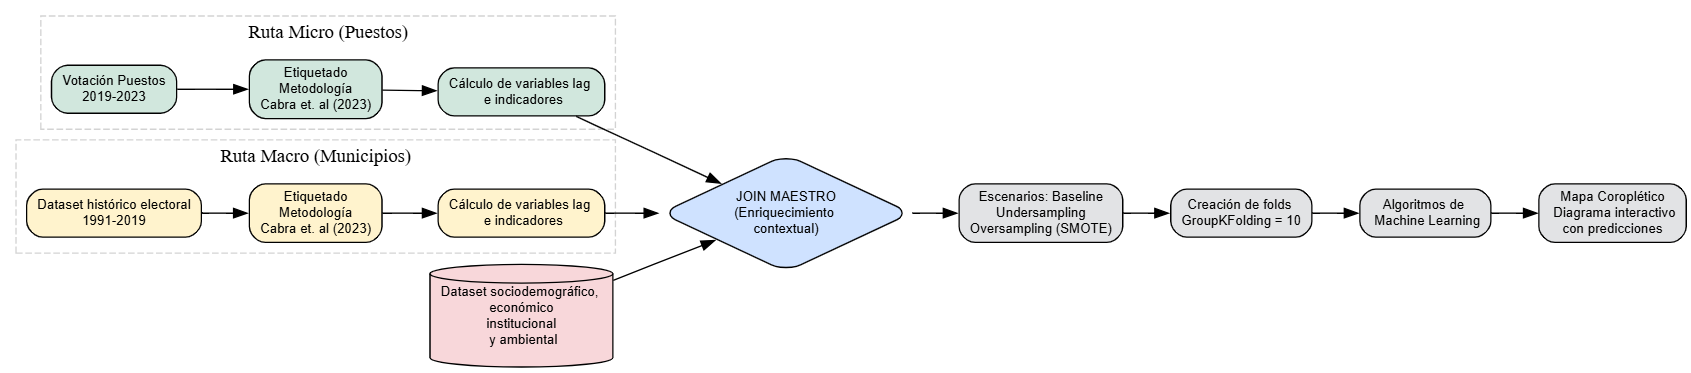



***Fase 1: Ingesta de fuentes heterogéneas***

El proyecto opera sobre una arquitectura de datos de tres capas, diferenciando el origen por su granularidad y naturaleza:

1.	Ruta macro (histórica): Un datamart electoral que consolida resultados municipales desde 1991 hasta 2019. Captura la inercia histórica y las tendencias de largo plazo.
2.	Capa estructural (socioeconómica): El archivo Cauca_Limpio.xlsx, que provee el contexto demográfico (población indígena, afro, ruralidad) y económico (PIB, ingresos fiscales). Presenta los factores macro que condicionan el comportamiento electoral.
3.	Ruta micro (coyuntural): Resultados desagregados de 2023 a nivel de Puesto de Votación. Esta capa permite realizar una micro-focalización territorial, pasando del análisis de municipios al análisis de pequeñas áreas.

***Fase 2: Arquitectura de Fusión y Estandarización***

En esta fase, los datos pasan por un proceso de refinamiento para asegurar la integridad del "Join Maestro":



*   Normalización: Se aplica una limpieza estricta (minúsculas, eliminación de tildes y caracteres especiales) para evitar errores en el cruce de llaves.
*   Etiquetado político (Cabra et al., 2023): Se trasciende el código numérico del partido. Aplicando una taxonomía académica, los cientos de siglas se agrupan en categorías interpretables como "Identitario Étnico", "Tradicional", "Ex-militantes", etc.


*   Convergencia (join maestro): En este paso se produce el enriquecimiento contextual. Los datos electorales (micro y macro) se fusionan con el dataset socioeconómico mediante el código de municipio (codmpio).


***Fase 3: Ingeniería de Variables e Inferencia Ecológica***

Se construye mediante la transformación de variables:

*   Binarización del objetivo: El porcentaje de voto indígena se transforma en una variable lógica (1 = Bastión, 0 = No Bastión) mediante un umbral justificado estadísticamente (ej. 32%).
*   Variables de rezago (cross-lagging): Se crean los features lag_19_*. Para cada puesto de 2023, se le asigna el historial de 2019 de su municipio en diversas corporaciones (Alcaldía, Concejo, Asamblea). Esto dota al modelo de capacidad de asociar la votación para la Gobernación con el comportamiento electoral de otras corporaciones en el mismo período.
*   Codificación nominal: Se aplica One-Hot Encoding a las variables categóricas, permitiendo que los algoritmos procesen identidades territoriales y tipos de elección sin sesgos de orden.

***Fase 4: Modelamiento Experimental con enfoque espacial***

Se implementa una evaluación cruzada de algoritmos bajo condiciones controladas:
*   Validación cruzada agrupada (groupkfold k=10): Para evitar la "fuga de datos", la validación se agrupa por municipio. Esto garantiza que el modelo aprenda patrones territoriales generales y no memorice municipios específicos.
*   Diversidad algorítmica: Se evalúan cinco familias: Árboles de Decisión, Random Forest, XGBoost, Regresión Logística y Naive Bayes.
*   Escenarios de balanceo: Dado que los bastiones son minoría, se prueban tres entornos:
1.	Baseline: Datos originales.
2.	Undersampling: Reducción de la clase mayoritaria.
3.	SMOTE: Creación sintética de ejemplos de la clase minoritaria (Bastiones).

***Fase 5: Evaluación del desempeño de los modelos***

No solo se busca precisión, sino explicabilidad. Una vez seleccionado el Modelo Campeón (XGBoost), se somete a:
*   Métricas de desbalanceo: Se prioriza el F1-Score y el Recall sobre la exactitud, para asegurar que el modelo sea capaz de encontrar los bastiones reales.
*   Importancia global (feature importance): Ranking de variables según su capacidad de reducción de incertidumbre (Gain).
*   Interpretabilidad SHAP: Basada en teoría de juegos, descompone cada predicción para explicar cuánto aportó cada variable.

F***ase 6: Predicción, Despliegue y Visualización***

La fase final materializa el conocimiento en herramientas de toma de decisiones:
*   Predicción territorial: El modelo entrenado con la historia (1991-2019) se aplica sobre el dataset de 2023 enriquecido.
*   Síntesis cartográfica: Las probabilidades se exportan y visualizan en un mapa coroplético. Esto permite identificar geográficamente los puntos calientes de apoyo étnico, diferenciando entre bastiones consolidados, zonas en disputa y territorios de baja penetración.
*   Exportación para auditoría: Se generan archivos CSV hacia Google Drive, garantizando la reproducibilidad total de la investigación y su integración con sistemas de información geográfica (SIG).


## 0 · Instalación de dependencias

In [ ]:
import subprocess, sys

PAQUETES = ['shap', 'imbalanced-learn', 'xgboost']

for pkg in PAQUETES:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('✅ Dependencias instaladas.')

✅ Dependencias instaladas.


## 1 · Configuración centralizada



In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os

# ── Única línea que debes cambiar ─────────────────────────────────────────────
BASE_DIR = '/content/drive/My Drive/Documentos varios/MAIN/3er Semestre'

# ── Configuración completa del experimento ────────────────────────────────────
CONFIG = dict(

    # Archivos de entrada
    ruta_historico    = os.path.join(BASE_DIR, 'datamart_analitico_cauca_1991_2019.csv'),
    ruta_socio        = os.path.join(BASE_DIR, 'Cauca_Limpio.xlsx'),
    ruta_electoral_23 = os.path.join(BASE_DIR, 'Cauca_23_etiquetado.csv'),
    ruta_mapa_23      = os.path.join(BASE_DIR, 'Nuevo dataset/Partidos_movimientos_unicos_23.xlsx'),
    ruta_puestos_19   = os.path.join(BASE_DIR, 'Nuevo dataset/Puestos_votacion_Cauca_etiqueta_2019.xlsx'),

    # Directorio de puntos de control
    checkpoint_dir    = os.path.join(BASE_DIR, 'checkpoints_v3'),

    # Parámetros del experimento
    SEED              = 42,
    TARGET_COL        = 'porc_indigenas',
    TIPO_ELECCION     = 'Gobernación',
    TEST_SIZE         = 0.20,

    # Umbral principal (justificado en Sección 4)
    UMBRAL            = 32.0,

    # Umbrales alternativos para análisis de sensibilidad
    UMBRALES_SENS     = [20.0, 25.0, 28.0, 30.0, 32.0, 35.0, 40.0],

    # Años usados como corte de validación temporal
    # El modelo entrena con todos los años ANTERIORES a cada corte
    ANIOS_VALIDACION  = [2007, 2011, 2015, 2019],

    # Hiperparámetros de modelos
    RF_N_ESTIMATORS   = 150,
    DT_MAX_DEPTH      = 6,
)

os.makedirs(CONFIG['checkpoint_dir'], exist_ok=True)

print('✅ Configuración cargada.')
print(f"   BASE_DIR         : {BASE_DIR}")
print(f"   Umbral principal : {CONFIG['UMBRAL']}%")
print(f"   Semilla global   : {CONFIG['SEED']}")
print(f"   Folds temporales : {CONFIG['ANIOS_VALIDACION']}")

Mounted at /content/drive
✅ Configuración cargada.
   BASE_DIR         : /content/drive/My Drive/Documentos varios/MAIN/3er Semestre
   Umbral principal : 32.0%
   Semilla global   : 42
   Folds temporales : [2007, 2011, 2015, 2019]


## 2 · Módulo de utilidades

> Todas las funciones reutilizables están aquí

In [ ]:
# ── Importaciones ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

import shap
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.model_selection import train_test_split
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay,
    roc_curve, auc, f1_score, roc_auc_score
)
from xgboost import XGBClassifier

SEED = CONFIG['SEED']


# ─────────────────────────────────────────────────────────────────────────────
# UTILIDADES GENERALES
# ─────────────────────────────────────────────────────────────────────────────

def limpiar_columnas(df: pd.DataFrame) -> pd.DataFrame:
    """Estandariza nombres de columnas: minúsculas, sin tildes, sin espacios ni puntos."""
    trad = str.maketrans('áéíóúÁÉÍÓÚñÑ', 'aeiouAEIOUnN')
    df.columns = [
        col.lower().translate(trad).replace(' ', '_').replace('.', '_')
        for col in df.columns
    ]
    return df


def checkpoint_guardar(obj, nombre: str) -> None:
    """Serializa un objeto en disco para evitar recomputación."""
    ruta = os.path.join(CONFIG['checkpoint_dir'], f'{nombre}.pkl')
    joblib.dump(obj, ruta)
    print(f'  💾 Checkpoint guardado → {nombre}.pkl')


def checkpoint_cargar(nombre: str):
    """Carga un objeto desde disco. Retorna None si no existe."""
    ruta = os.path.join(CONFIG['checkpoint_dir'], f'{nombre}.pkl')
    if os.path.exists(ruta):
        print(f'  ⚡ Checkpoint encontrado → cargando {nombre}.pkl')
        return joblib.load(ruta)
    return None


def imputar_con_media_municipal(df: pd.DataFrame,
                                 col_mpio: str = 'codmpio') -> pd.DataFrame:
    """
    Imputa valores faltantes usando la media del propio municipio.
    Si el municipio completo tiene NaN para una columna, usa la media global.
    Es metodológicamente superior a imputar con cero porque preserva
    el perfil histórico de cada municipio.
    """
    df = df.copy()
    cols_nan = df.columns[df.isnull().any()].tolist()
    for col in cols_nan:
        media_muni   = df.groupby(col_mpio)[col].transform('mean')
        media_global = df[col].mean()
        df[col] = df[col].fillna(media_muni).fillna(media_global)
    return df


# ─────────────────────────────────────────────────────────────────────────────
# VALIDACIÓN TEMPORAL POR BLOQUES
# ─────────────────────────────────────────────────────────────────────────────

class TemporalBlockCV:
    """
    Validación cruzada por bloques de tiempo para datos electorales de panel.

    Problema que resuelve
    ---------------------
    GroupKFold agrupa por municipio pero puede mezclar años distintos en el
    mismo fold, permitiendo que el modelo 'vea el futuro' durante el
    entrenamiento. TemporalBlockCV garantiza que el modelo siempre entrena
    con años anteriores al año de validación.

    Ejemplo con ANIOS_VALIDACION = [2007, 2011, 2015, 2019]
    ---------------------------------------------------------
      Fold 1: entrena 1994–2003  → valida 2007
      Fold 2: entrena 1994–2007  → valida 2011
      Fold 3: entrena 1994–2011  → valida 2015
      Fold 4: entrena 1994–2015  → valida 2019
    """
    def __init__(self, anios_validacion: list, col_anio: str = 'ano'):
        self.anios_validacion = sorted(anios_validacion)
        self.col_anio = col_anio

    def split(self, X: pd.DataFrame):
        anio_series = X[self.col_anio].values
        for anio_val in self.anios_validacion:
            idx_train = np.where(anio_series <  anio_val)[0]
            idx_val   = np.where(anio_series == anio_val)[0]
            if len(idx_train) == 0 or len(idx_val) == 0:
                continue
            yield idx_train, idx_val

    @property
    def n_splits(self) -> int:
        return len(self.anios_validacion)

    def __repr__(self):
        return f'TemporalBlockCV(folds={self.anios_validacion})'


def _construir_pipeline_con_smote_seguro(modelo, sampler, ytr):
    """
    Construye el pipeline de entrenamiento ajustando k_neighbors de SMOTE
    al tamaño real de la clase minoritaria en el fold actual.
    Evita el ValueError cuando hay menos muestras que k_neighbors.
    """
    from imblearn.over_sampling import SMOTE as _SMOTE
    from imblearn.pipeline import Pipeline as _ImbPipeline

    if sampler is None:
        return modelo

    if isinstance(sampler, _SMOTE):
        n_min = int(pd.Series(ytr).value_counts().min())
        k_safe = max(1, min(sampler.k_neighbors, n_min - 1))
        if k_safe < sampler.k_neighbors:
            print(f'    [SMOTE] k_neighbors: {sampler.k_neighbors} → {k_safe} '
                  f'(clase minoritaria n={n_min})')
        sampler_fold = _SMOTE(random_state=sampler.random_state,
                              k_neighbors=k_safe)
    else:
        sampler_fold = sampler

    return _ImbPipeline([('sampler', sampler_fold), ('model', modelo)])


def cv_temporal(pipeline_o_modelo, df_con_anio: pd.DataFrame,
                y: pd.Series, cv: TemporalBlockCV) -> pd.DataFrame:
    """
    Ejecuta validación cruzada temporal y retorna un DataFrame
    con F1-weighted y AUC por fold.

    Acepta tanto modelos sklearn simples como ImbPipeline con sampler.
    En cada fold reconstruye el pipeline de forma segura, ajustando
    k_neighbors de SMOTE al tamaño real de la clase minoritaria.

    Parámetros
    ----------
    pipeline_o_modelo : estimador sklearn o ImbPipeline
    df_con_anio       : DataFrame con la columna 'ano' y todos los features
    y                 : variable objetivo alineada con df_con_anio
    cv                : instancia de TemporalBlockCV
    """
    from imblearn.pipeline import Pipeline as _ImbPipeline

    col_anio = cv.col_anio
    X_feat   = df_con_anio.drop(columns=[col_anio]).reset_index(drop=True)
    y_vals   = y.reset_index(drop=True)
    df_idx   = df_con_anio.reset_index(drop=True)

    # Descomponer pipeline en (sampler, modelo_base) para poder
    # reconstruirlo fold a fold con el k_neighbors correcto
    if (isinstance(pipeline_o_modelo, _ImbPipeline) and
            pipeline_o_modelo.steps[0][0] == 'sampler'):
        sampler_orig = pipeline_o_modelo.steps[0][1]
        modelo_base  = pipeline_o_modelo.steps[1][1]
    else:
        sampler_orig = None
        modelo_base  = pipeline_o_modelo

    registros = []

    for anio_val, (idx_tr, idx_val) in zip(
        cv.anios_validacion, cv.split(df_idx)
    ):
        Xtr, Xval = X_feat.iloc[idx_tr], X_feat.iloc[idx_val]
        ytr, yval = y_vals.iloc[idx_tr], y_vals.iloc[idx_val]

        # Guardia 1: fold inválido si train tiene una sola clase
        if ytr.nunique() < 2:
            print(f'  ⚠️  Fold {anio_val}: train con una sola clase '
                  f'(n={len(ytr)}, clases={sorted(ytr.unique())}). Omitido.')
            continue

        # Guardia 2: fold inválido si val tiene una sola clase (AUC indefinido)
        if yval.nunique() < 2:
            print(f'  ⚠️  Fold {anio_val}: val con una sola clase '
                  f'(n={len(yval)}, clases={sorted(yval.unique())}). Omitido.')
            continue

        # Construir pipeline fold-específico (ajusta SMOTE k si hace falta)
        pipeline_fold = _construir_pipeline_con_smote_seguro(
            modelo_base, sampler_orig, ytr
        )

        try:
            pipeline_fold.fit(Xtr, ytr)
        except Exception as e:
            print(f'  ⚠️  Fold {anio_val}: error al entrenar: {e}. Omitido.')
            continue

        # Guardia 3: predict_proba con 1 columna (DummyClassifier de una clase)
        proba_mat = pipeline_fold.predict_proba(Xval)
        if proba_mat.shape[1] < 2:
            print(f'  ⚠️  Fold {anio_val}: predict_proba con 1 columna. Omitido.')
            continue

        ypred  = pipeline_fold.predict(Xval)
        yproba = proba_mat[:, 1]

        fpr, tpr, _ = roc_curve(yval, yproba)
        registros.append({
            'fold_anio'   : anio_val,
            'n_train'     : len(idx_tr),
            'n_val'       : len(idx_val),
            'f1_weighted' : round(f1_score(yval, ypred, average='weighted'), 4),
            'roc_auc'     : round(auc(fpr, tpr), 4),
        })

    if not registros:
        print('  ⚠️  Ningún fold válido para este modelo/escenario.')
        return pd.DataFrame(columns=[
            'fold_anio', 'n_train', 'n_val', 'f1_weighted', 'roc_auc'
        ])

    return pd.DataFrame(registros)


# ─────────────────────────────────────────────────────────────────────────────
# DEFINICIÓN DE MODELOS# DEFINICIÓN DE MODELOS Y ESCENARIOS
# ─────────────────────────────────────────────────────────────────────────────

def construir_modelos(seed: int = SEED) -> dict:
    """
    Retorna un diccionario de modelos recién instanciados (sin estado previo).
    Incluye dos baselines triviales como piso de comparación.
    Centralizar aquí garantiza hiperparámetros consistentes en todo el notebook.
    """
    return {
        # ── Baselines triviales ──────────────────────────────────────────────
        'Baseline_Mayoria' : DummyClassifier(strategy='most_frequent', random_state=seed),
        'Baseline_Estrat'  : DummyClassifier(strategy='stratified',    random_state=seed),
        # ── Modelos ML ──────────────────────────────────────────────────────
        'DecisionTree'     : DecisionTreeClassifier(
                                 max_depth=CONFIG['DT_MAX_DEPTH'], random_state=seed),
        'RandomForest'     : RandomForestClassifier(
                                 n_estimators=CONFIG['RF_N_ESTIMATORS'], random_state=seed,
                                 n_jobs=-1),
        'XGBoost'          : XGBClassifier(
                                 eval_metric='logloss', random_state=seed, verbosity=0),
        'LogReg'           : Pipeline([
                                 ('scaler', StandardScaler()),
                                 ('lr', LogisticRegression(
                                     max_iter=1000, solver='liblinear', random_state=seed))
                             ]),
        'NaiveBayes'       : Pipeline([
                                 ('scaler', StandardScaler()),
                                 ('nb', GaussianNB())
                             ]),
    }


def smote_adaptativo(seed: int = SEED, k: int = 5) -> SMOTE:
    """
    Retorna una instancia de SMOTE con k_neighbors configurado.
    En cv_temporal se usa smote_adaptativo(k=min_clase-1) para
    evitar el error cuando hay muy pocos ejemplos de la clase
    minoritaria en un fold temporal pequeño.
    """
    return SMOTE(random_state=seed, k_neighbors=k)


ESCENARIOS = [
    ('Baseline',      None),
    ('Undersampling', RandomUnderSampler(random_state=SEED)),
    ('SMOTE',         smote_adaptativo(k=5)),  # k se ajusta en cv_temporal si es necesario
]


# ─────────────────────────────────────────────────────────────────────────────
# EVALUACIÓN E INTERPRETABILIDAD
# ─────────────────────────────────────────────────────────────────────────────

def evaluar_modelo(nombre: str, modelo,
                   X_train, y_train,
                   X_test,  y_test,
                   top_n: int = 10) -> dict:
    """
    Entrena un modelo sobre X_train/y_train, lo evalúa sobre X_test/y_test
    y genera los siguientes instrumentos de interpretabilidad:
      1. Reporte de clasificación (Precision / Recall / F1 por clase)
      2. Matriz de confusión + Curva ROC (figura lado a lado)
      3. Feature Importance (Gini/Gain para árboles, |coef| para LogReg)
      4. Gráficos de Dependencia Parcial (PDP) para el top-4 de variables
      5. SHAP summary bar + beeswarm

    Retorna un diccionario con el modelo entrenado y las métricas principales.
    """
    print(f'\n{"═"*72}')
    print(f'  {nombre}')
    print(f'{"═"*72}')

    modelo.fit(X_train, y_train)
    y_pred  = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]

    # 1. Reporte de clasificación
    print(classification_report(
        y_test, y_pred, target_names=['No Bastión', 'Bastión']
    ))

    # 2. Matriz de confusión + Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_val     = auc(fpr, tpr)
    f1_val      = f1_score(y_test, y_pred, average='weighted')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ConfusionMatrixDisplay.from_estimator(
        modelo, X_test, y_test, ax=axes[0], cmap='Blues',
        display_labels=['No Bastión', 'Bastión']
    )
    axes[0].set_title(f'Matriz de confusión — {nombre}')

    axes[1].plot(fpr, tpr, lw=2, color='steelblue',
                 label=f'AUC = {roc_val:.3f}')
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[1].set(xlabel='Tasa Falsos Positivos',
                ylabel='Tasa Verdaderos Positivos',
                title=f'Curva ROC — {nombre}')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    # 3. Feature importance
    top_features = []
    if hasattr(modelo, 'feature_importances_'):
        imp = (pd.DataFrame({'Feature'    : X_train.columns,
                              'Importancia': modelo.feature_importances_})
               .sort_values('Importancia', ascending=False))
        top_features = imp['Feature'].head(4).tolist()
        fig, ax = plt.subplots(figsize=(10, 5))
        sns.barplot(data=imp.head(top_n), x='Importancia', y='Feature',
                    ax=ax, palette='rocket')
        ax.set_title(f'Feature Importance (Gini/Gain) — {nombre}')
        plt.tight_layout()
        plt.show()

    elif hasattr(modelo, 'named_steps') and 'lr' in modelo.named_steps:
        coef = modelo.named_steps['lr'].coef_[0]
        imp  = (pd.DataFrame({'Feature'  : X_train.columns,
                               'Coef'     : coef,
                               'AbsCoef'  : np.abs(coef)})
                .sort_values('AbsCoef', ascending=False))
        top_features = imp['Feature'].head(4).tolist()
        fig, ax = plt.subplots(figsize=(10, 5))
        sns.barplot(data=imp.head(top_n), x='Coef', y='Feature',
                    ax=ax, palette='coolwarm')
        ax.axvline(0, color='black', lw=0.8)
        ax.set_title(f'Coeficientes — {nombre}')
        plt.tight_layout()
        plt.show()

    # 4. Gráficos de Dependencia Parcial (PDP)
    if top_features:
        try:
            fig, ax = plt.subplots(figsize=(14, 5))
            PartialDependenceDisplay.from_estimator(
                modelo, X_train, features=top_features,
                ax=ax, kind='average'
            )
            plt.suptitle(
                f'Dependencia Parcial (PDP) — {nombre}\n'
                f'Cómo cambia la probabilidad predicha al variar cada variable',
                y=1.02
            )
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f'  [PDP] No disponible para {nombre}: {e}')

    # 5. SHAP
    try:
        n_muestra   = min(150, len(X_train))
        X_sample    = shap.sample(X_train, n_muestra, random_state=SEED)
        shap_values = None

        if nombre in ['DecisionTree', 'RandomForest', 'XGBoost']:
            explainer   = shap.TreeExplainer(modelo)
            shap_values = explainer.shap_values(X_sample)

        elif nombre == 'LogReg':
            scaler      = modelo.named_steps['scaler']
            lr_mod      = modelo.named_steps['lr']
            Xs          = scaler.transform(X_sample)
            explainer   = shap.LinearExplainer(lr_mod, Xs)
            shap_values = explainer.shap_values(Xs)
            X_sample    = pd.DataFrame(Xs, columns=X_train.columns)

        else:
            print(f'  [SHAP] Omitido para {nombre} (costo computacional elevado).')

        if shap_values is not None:
            shap.summary_plot(shap_values, X_sample,
                              plot_type='bar', max_display=top_n, show=False)
            plt.title(f'SHAP — Importancia global ({nombre})')
            plt.show()

            shap.summary_plot(shap_values, X_sample,
                              max_display=top_n, show=False)
            plt.title(f'SHAP — Dirección del impacto ({nombre})')
            plt.show()

    except Exception as e:
        print(f'  [SHAP] Error en {nombre}: {e}')

    return {'nombre': nombre, 'modelo': modelo,
            'auc': roc_val, 'f1': f1_val}


print('✅ Módulo de utilidades cargado.')
print(f'   Modelos disponibles: {list(construir_modelos().keys())}')
print(f'   Escenarios          : {[e[0] for e in ESCENARIOS]}')
print(f'   CV temporal         : {TemporalBlockCV(CONFIG["ANIOS_VALIDACION"])}')

✅ Módulo de utilidades cargado.
   Modelos disponibles: ['Baseline_Mayoria', 'Baseline_Estrat', 'DecisionTree', 'RandomForest', 'XGBoost', 'LogReg', 'NaiveBayes']
   Escenarios          : ['Baseline', 'Undersampling', 'SMOTE']
   CV temporal         : TemporalBlockCV(folds=[2007, 2011, 2015, 2019])


## 3 · Carga y construcción del datamart

In [ ]:
# ── AGREGAR GOBERNACIÓN 2019 AL DATAMART MUNICIPAL ────────────────────────────

# ── 0. Garantizar que df_entrenamiento existe en memoria ──────────────────────
if 'df_entrenamiento' not in dir() or df_entrenamiento is None:
    print("df_entrenamiento no encontrado en memoria → cargando desde checkpoint...")
    df_entrenamiento = checkpoint_cargar('df_entrenamiento')
    if df_entrenamiento is None:
        raise RuntimeError(
            "No se encontró df_entrenamiento ni en memoria ni en checkpoint.\n"
            "Ejecuta primero la celda 8 (Sección 3 · Carga del datamart)."
        )
    print(f"✅ Cargado. Shape: {df_entrenamiento.shape}")
else:
    print(f"✅ df_entrenamiento ya en memoria. Shape: {df_entrenamiento.shape}")

# Verificar que 2019 no esté ya agregado (evitar doble inserción)
anios_gob = sorted(
    df_entrenamiento[
        df_entrenamiento['tipo_eleccion'] == 'Gobernación'
    ]['ano'].unique()
)
print(f"Años de Gobernación actualmente en el datamart: {anios_gob}")

if 2019.0 in anios_gob or 2019 in anios_gob:
    print("✅ 2019 ya está en el datamart. Celda omitida.")
else:
    print("⚙️  2019 no está en el datamart → procediendo a agregarlo...\n")

    # ── 1. Cargar puestos 2019 y filtrar Gobernación ──────────────────────────
    df_p19 = limpiar_columnas(pd.read_excel(CONFIG['ruta_puestos_19']))

    # Traducir código corto → DANE usando nombre_municipio como puente
    ALIASES_19 = {
        'LOPEZ (MICAY)'     : 'LOPEZ DE MICAY',
        'PAEZ (BELALCAZAR)' : 'PAEZ',
        'PURACE (COCONUCO)' : 'PURACE',
        'SOTARA (PAISPAMBA)': 'SOTARA',
    }

    mapa_dane_19 = (df_entrenamiento[['codmpio', 'municipio']]
                    .drop_duplicates()
                    .assign(municipio_key=lambda d:
                            d['municipio'].str.upper().str.strip()))

    df_p19['municipio_key'] = (df_p19['nombre_municipio']
                                .str.upper().str.strip()
                                .replace(ALIASES_19))
    df_p19 = pd.merge(
        df_p19,
        mapa_dane_19[['municipio_key', 'codmpio']].rename(
            columns={'codmpio': 'codmpio_dane'}),
        on='municipio_key', how='left'
    )
    df_p19['codmpio'] = df_p19['codmpio_dane']
    df_p19.drop(columns=['municipio_key', 'codmpio_dane'],
                inplace=True, errors='ignore')

    # Filtrar Gobernador y votos válidos
    INVALIDAS = ['BLANCOS/NULOS/NO MARCADOS', 'INFORMACIÓN INSUFICIENTE',
                 'INFORMACION INSUFICIENTE', 'SIN ETIQUETA']
    df_gob19 = df_p19[
        (df_p19['nombre_corporacion'].str.upper() == 'GOBERNADOR') &
        (df_p19['etiqueta_partido_uniandes'].notna()) &
        (~df_p19['etiqueta_partido_uniandes'].astype(str).str.upper()
         .isin([v.upper() for v in INVALIDAS]))
    ].copy()
    df_gob19.rename(
        columns={'etiqueta_partido_uniandes': 'etiqueta_final'}, inplace=True
    )

    print(f"Registros válidos Gobernación 2019 : {len(df_gob19)}")
    print(f"Municipios con datos               : {df_gob19['codmpio'].nunique()}")
    print(f"Etiquetas disponibles              : {sorted(df_gob19['etiqueta_final'].unique())}")

    # ── 2. Calcular porcentajes por etiqueta a nivel municipal ────────────────
    votos_etq = (df_gob19
        .groupby(['codmpio', 'etiqueta_final'])['total_votos']
        .sum().reset_index())
    votos_tot = (df_gob19
        .groupby('codmpio')['total_votos']
        .sum().reset_index()
        .rename(columns={'total_votos': 'votos_totales'}))

    df_porc19 = pd.merge(votos_etq, votos_tot, on='codmpio')
    df_porc19['porc'] = (
        df_porc19['total_votos'] / df_porc19['votos_totales'] * 100
    ).round(4)

    df_muni19 = (df_porc19
        .pivot_table(index='codmpio',
                     columns='etiqueta_final',
                     values='porc',
                     fill_value=0)
        .reset_index())

    df_muni19.columns = (
        ['codmpio'] +
        [f"porc_{c.lower().replace(' ', '_').replace('/', '_')}"
         for c in df_muni19.columns if c != 'codmpio']
    )

    # ── 3. Verificar y normalizar columna indígenas ───────────────────────────
    col_ind = [c for c in df_muni19.columns if 'indig' in c.lower()]
    print(f"\nColumna indígenas detectada: {col_ind}")
    if not col_ind:
        raise ValueError(
            "No se encontró columna de voto indígena.\n"
            f"Columnas disponibles: {list(df_muni19.columns)}"
        )
    if col_ind[0] != 'porc_indigenas':
        df_muni19.rename(columns={col_ind[0]: 'porc_indigenas'}, inplace=True)
        print(f"  Renombrado: {col_ind[0]} → porc_indigenas")

    # ── 4. Añadir columnas de contexto ────────────────────────────────────────
    df_muni19['ano']           = 2019
    df_muni19['tipo_eleccion'] = 'Gobernación'

    # Fragmentación (Herfindahl) y dominancia
    cols_porc = [c for c in df_muni19.columns if c.startswith('porc_')]
    proporciones = df_muni19[cols_porc].div(100)
    df_muni19['fragmentacion'] = 1 - (proporciones ** 2).sum(axis=1)
    df_muni19['dominancia']    = proporciones.max(axis=1)

    # Nombre del municipio
    df_muni19 = pd.merge(
        df_muni19,
        mapa_dane_19[['codmpio', 'municipio']],
        on='codmpio', how='left'
    )
    df_muni19.rename(columns={'municipio': 'municipio_elec'}, inplace=True)

    print(f"\ndf_muni19 shape : {df_muni19.shape}")
    print(f"Bastiones 2019 (≥{CONFIG['UMBRAL']}%) : "
          f"{(df_muni19['porc_indigenas'] >= CONFIG['UMBRAL']).sum()} "
          f"/ {len(df_muni19)}")
    print("\nTop 10 municipios por % indígena Gobernación 2019:")
    display(df_muni19[['municipio_elec', 'porc_indigenas',
                        'fragmentacion', 'dominancia']]
            .sort_values('porc_indigenas', ascending=False)
            .head(10))

    # ── 5. Alinear columnas y concatenar ──────────────────────────────────────
    cols_faltantes = [c for c in df_entrenamiento.columns
                      if c not in df_muni19.columns]
    for col in cols_faltantes:
        df_muni19[col] = 0

    df_muni19_alineado = df_muni19[df_entrenamiento.columns].copy()

    df_entrenamiento_nuevo = pd.concat(
        [df_entrenamiento, df_muni19_alineado],
        ignore_index=True
    )

    # ── 6. Validar resultado ──────────────────────────────────────────────────
    print("\n── Bastiones históricos por año (datamart ampliado) ─────────────")
    check = (
        df_entrenamiento_nuevo[
            df_entrenamiento_nuevo['tipo_eleccion'] == 'Gobernación'
        ]
        .groupby('ano')
        .agg(
            municipios = ('codmpio',              'nunique'),
            bastiones  = (CONFIG['TARGET_COL'],
                          lambda x: (x >= CONFIG['UMBRAL']).sum())
        )
        .assign(pct_bastion=lambda d:
                (d['bastiones'] / d['municipios'] * 100).round(1))
    )
    print(check.to_string())

    # ── 7. Guardar y limpiar checkpoints afectados ────────────────────────────
    df_entrenamiento = df_entrenamiento_nuevo
    checkpoint_guardar(df_entrenamiento, 'df_entrenamiento')

    for ck in ['df_cv_temporal']:
        ruta_ck = os.path.join(CONFIG['checkpoint_dir'], f'{ck}.pkl')
        if os.path.exists(ruta_ck):
            os.remove(ruta_ck)
            print(f"💾 Checkpoint {ck}.pkl eliminado → se reejecutará")

    # ── 8. Actualizar ANIOS_VALIDACION ────────────────────────────────────────
    CONFIG['ANIOS_VALIDACION'] = [2007, 2011, 2015, 2019]
    print(f"\n✅ Datamart ampliado con Gobernación 2019.")
    print(f"   ANIOS_VALIDACION actualizado: {CONFIG['ANIOS_VALIDACION']}")
    print("\n→ Ejecuta ahora las Secciones 5, 6, 8, 9 y 10 en orden.")

df_entrenamiento no encontrado en memoria → cargando desde checkpoint...
  ⚡ Checkpoint encontrado → cargando df_entrenamiento.pkl
✅ Cargado. Shape: (1993, 30)
Años de Gobernación actualmente en el datamart: [np.float64(1994.0), np.float64(1997.0), np.float64(2000.0), np.float64(2003.0), np.float64(2007.0), np.float64(2011.0), np.float64(2015.0), np.float64(2019.0)]
✅ 2019 ya está en el datamart. Celda omitida.


## 4 · Análisis de sensibilidad al umbral

> Esta sección justifica cuantitativamente la elección del umbral principal.  
> Ejecuta antes de continuar con el pipeline para tener el argumento listo.

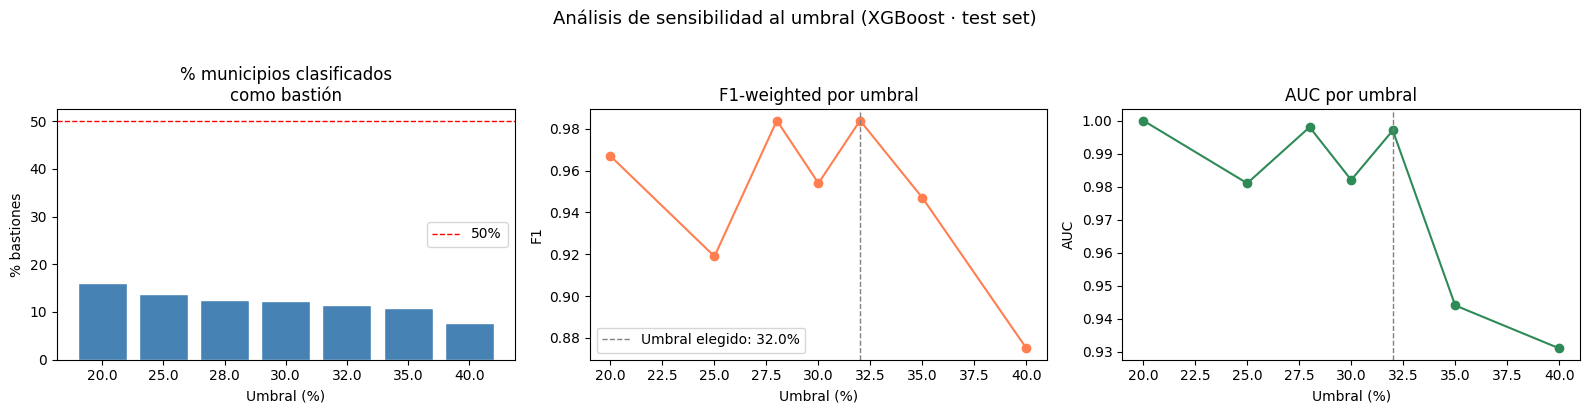

Tabla de resultados por umbral:


,Umbral (%),% Bastiones,F1-weighted,AUC
0,20.0,16.0,0.967,1.000
1,25.0,13.8,0.919,0.981
2,28.0,12.5,0.984,0.998
3,30.0,12.2,0.954,0.982
4,32.0,11.5,0.984,0.997
5,35.0,10.9,0.947,0.944
6,40.0,7.7,0.875,0.931



→ Umbral seleccionado para el resto del pipeline: 32.0%
  Sustituye este bloque con la justificación sustantiva en la tesis.


In [ ]:
# ── Análisis de sensibilidad al umbral ───────────────────────────────────────
# Corre XGBoost con cada umbral de CONFIG['UMBRALES_SENS'] y registra:
#   - Distribución de clases resultante
#   - F1-weighted en test set
#   - AUC en test set

df_gob = df_entrenamiento[
    df_entrenamiento['tipo_eleccion'] == CONFIG['TIPO_ELECCION']
].copy()

registros_sens = []
COLS_ID = ['codmpio', 'municipio_elec', 'tipo_eleccion', 'ano']

for umbral in CONFIG['UMBRALES_SENS']:
    df_tmp = df_gob.copy()
    df_tmp['objetivo'] = (df_tmp[CONFIG['TARGET_COL']] >= umbral).astype(int)
    prop_pos = df_tmp['objetivo'].mean()

    X_tmp = df_tmp.drop(
        columns=[c for c in [CONFIG['TARGET_COL'], 'objetivo'] + COLS_ID
                 if c in df_tmp.columns],
        errors='ignore'
    )
    X_tmp = pd.get_dummies(X_tmp, drop_first=True, dtype=int)
    y_tmp = df_tmp['objetivo']

    if X_tmp.shape[0] < 20 or y_tmp.nunique() < 2:
        continue

    Xtr, Xte, ytr, yte = train_test_split(
        X_tmp, y_tmp, test_size=0.2, random_state=SEED, stratify=y_tmp
    )
    mod = XGBClassifier(eval_metric='logloss', random_state=SEED, verbosity=0)
    mod.fit(Xtr, ytr)

    ypred = mod.predict(Xte)
    yprob = mod.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(yte, yprob)

    registros_sens.append({
        'Umbral (%)'  : umbral,
        '% Bastiones' : round(prop_pos * 100, 1),
        'F1-weighted' : round(f1_score(yte, ypred, average='weighted'), 3),
        'AUC'         : round(auc(fpr, tpr), 3),
    })

df_sens = pd.DataFrame(registros_sens)

# ── Visualización ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
umbrales_str = df_sens['Umbral (%)'].astype(str)

axes[0].bar(umbrales_str, df_sens['% Bastiones'], color='steelblue', edgecolor='white')
axes[0].axhline(50, color='red', ls='--', lw=1, label='50%')
axes[0].set(title='% municipios clasificados\ncomo bastión',
            xlabel='Umbral (%)', ylabel='% bastiones')
axes[0].legend()

axes[1].plot(df_sens['Umbral (%)'], df_sens['F1-weighted'],
             marker='o', color='coral')
axes[1].axvline(CONFIG['UMBRAL'], color='gray', ls='--', lw=1,
                label=f"Umbral elegido: {CONFIG['UMBRAL']}%")
axes[1].set(title='F1-weighted por umbral',
            xlabel='Umbral (%)', ylabel='F1')
axes[1].legend()

axes[2].plot(df_sens['Umbral (%)'], df_sens['AUC'],
             marker='o', color='seagreen')
axes[2].axvline(CONFIG['UMBRAL'], color='gray', ls='--', lw=1)
axes[2].set(title='AUC por umbral',
            xlabel='Umbral (%)', ylabel='AUC')

plt.suptitle(
    'Análisis de sensibilidad al umbral (XGBoost · test set)',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

print('Tabla de resultados por umbral:')
display(df_sens)
print(f"\n→ Umbral seleccionado para el resto del pipeline: {CONFIG['UMBRAL']}%")
print('  Sustituye este bloque con la justificación sustantiva en la tesis.')

## 5 · Preparación del feature set

In [ ]:
# ── Preparación del feature set ───────────────────────────────────────────────

UMBRAL = CONFIG['UMBRAL']

# 1. Filtrar Gobernación y crear variable objetivo
df_gob = df_entrenamiento[
    df_entrenamiento['tipo_eleccion'] == CONFIG['TIPO_ELECCION']
].copy()
df_gob['objetivo'] = (df_gob[CONFIG['TARGET_COL']] >= UMBRAL).astype(int)

print(f'Distribución de clases (umbral = {UMBRAL}%):')
dist = df_gob['objetivo'].value_counts(normalize=True).rename(
    {0: 'No Bastión (0)', 1: 'Bastión (1)'}
)
print(dist.to_string())

# 2. Columnas a excluir del feature set
# 'ano' se conserva en df_ml para la validación temporal
# y se elimina de X_train/X_test antes de entrenar
COLS_EXCLUIR = [
    CONFIG['TARGET_COL'], 'objetivo',
    'municipio_elec', 'tipo_eleccion', 'departamento'
]
df_ml = df_gob.drop(
    columns=[c for c in COLS_EXCLUIR if c in df_gob.columns]
)
df_ml = pd.get_dummies(df_ml, drop_first=True, dtype=int)
y     = df_gob['objetivo'].reset_index(drop=True)
df_ml = df_ml.reset_index(drop=True)

# 3. Split train / test (holdout final, completamente apartado)
df_train_full, df_test, y_train_full, y_test = train_test_split(
    df_ml, y,
    test_size  = CONFIG['TEST_SIZE'],
    random_state = SEED,
    stratify   = y
)

# 4. Feature matrices para entrenamiento (sin la columna 'ano')
X_train_full = df_train_full.drop(columns=['ano'], errors='ignore')
X_test       = df_test.drop(columns=['ano'], errors='ignore')

print(f'\nShape train : {X_train_full.shape}')
print(f'Shape test  : {X_test.shape}')
print(f'Features    : {X_train_full.shape[1]}')

Distribución de clases (umbral = 32.0%):
objetivo
No Bastión (0)    0.884615
Bastión (1)       0.115385

Shape train : (249, 72)
Shape test  : (63, 72)
Features    : 72


## 6 · Validación temporal por bloques

> **Mejora metodológica central.**  
> El modelo siempre entrena con años anteriores al año de validación,  
> evitando que 'vea el futuro' dentro de cada fold.

TemporalBlockCV(folds=[2007, 2011, 2015, 2019])

  ⚠️  Fold 2007: train con una sola clase (n=117, clases=[np.int64(0)]). Omitido.
  ⚠️  Fold 2015: val con una sola clase (n=33, clases=[np.int64(0)]). Omitido.
  ⚠️  Fold 2019: val con una sola clase (n=30, clases=[np.int64(0)]). Omitido.
  ⚠️  Fold 2007: train con una sola clase (n=117, clases=[np.int64(0)]). Omitido.
  ⚠️  Fold 2015: val con una sola clase (n=33, clases=[np.int64(0)]). Omitido.
  ⚠️  Fold 2019: val con una sola clase (n=30, clases=[np.int64(0)]). Omitido.
  ⚠️  Fold 2007: train con una sola clase (n=117, clases=[np.int64(0)]). Omitido.
    [SMOTE] k_neighbors: 5 → 2 (clase minoritaria n=3)
  ⚠️  Fold 2015: val con una sola clase (n=33, clases=[np.int64(0)]). Omitido.
  ⚠️  Fold 2019: val con una sola clase (n=30, clases=[np.int64(0)]). Omitido.
  ⚠️  Fold 2007: train con una sola clase (n=117, clases=[np.int64(0)]). Omitido.
  ⚠️  Fold 2015: val con una sola clase (n=33, clases=[np.int64(0)]). Omitido.
  ⚠️  Fold 2019

F1-weighted        AUC    
                                      mean std   mean std
Modelo           Escenario                               
LogReg           Baseline            0.090 NaN  0.909 NaN
XGBoost          Baseline            0.090 NaN  0.861 NaN
RandomForest     Undersampling       0.148 NaN  0.673 NaN
                 SMOTE               0.090 NaN  0.668 NaN
LogReg           SMOTE               0.090 NaN  0.591 NaN
DecisionTree     Undersampling       0.148 NaN  0.519 NaN
NaiveBayes       Undersampling       0.148 NaN  0.519 NaN
XGBoost          SMOTE               0.090 NaN  0.519 NaN
NaiveBayes       Baseline            0.090 NaN  0.500 NaN
Baseline_Estrat  Baseline            0.090 NaN  0.500 NaN
LogReg           Undersampling       0.090 NaN  0.500 NaN
Baseline_Mayoria Baseline            0.090 NaN  0.500 NaN
                 SMOTE               0.090 NaN  0.500 NaN
                 Undersampling       0.090 NaN  0.500 NaN
NaiveBayes       SMOTE               0.090 NaN  0.500 NaN
DecisionTree     Baseline            0.090 NaN  0.500 NaN
                 SMOTE               0.090 NaN  0.500 NaN
XGBoost          Undersampling       0.090 NaN  0.500 NaN
RandomForest     Baseline            0.090 NaN  0.361 NaN
Baseline_Estrat  SMOTE               0.428 NaN  0.293 NaN
                 Undersampling       0.428 NaN  0.293 NaN

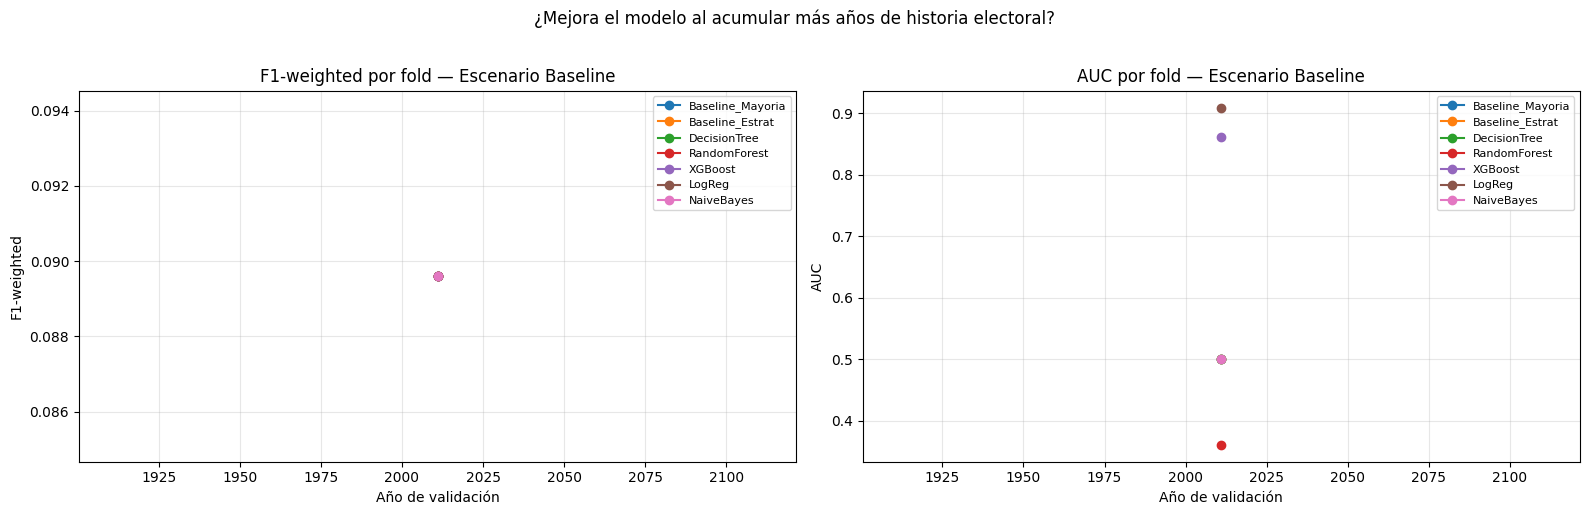

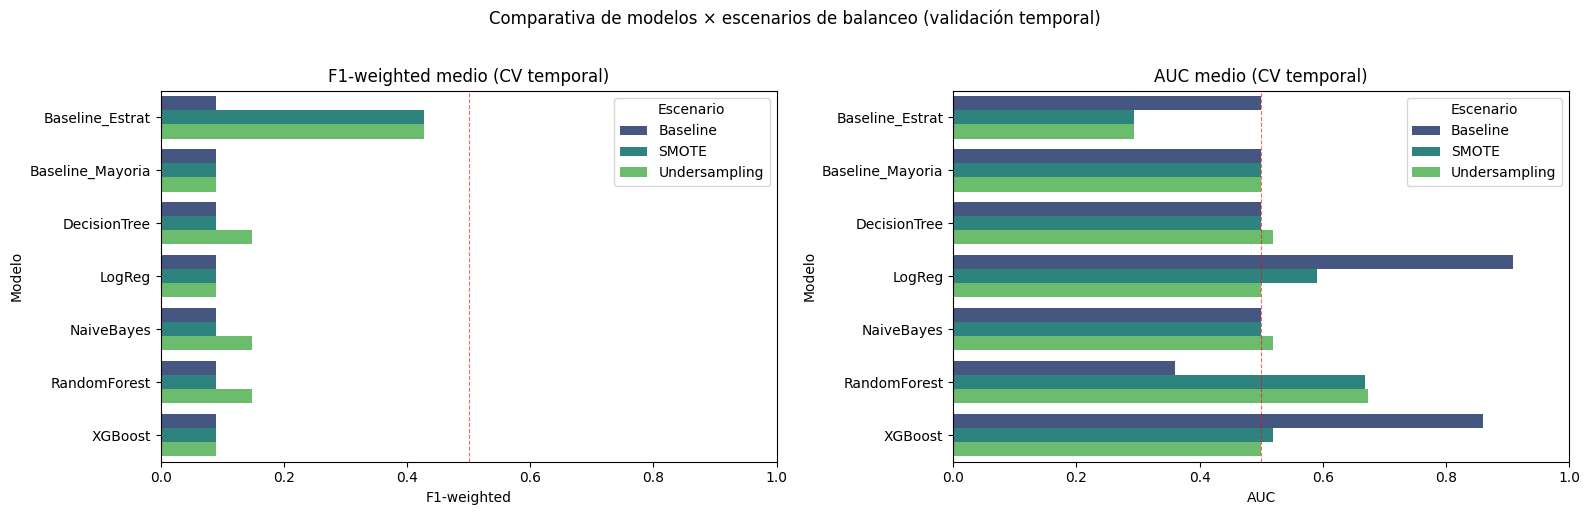

In [ ]:
# ── Validación temporal por bloques ───────────────────────────────────────────

df_cv_resultado = checkpoint_cargar('df_cv_temporal')

if df_cv_resultado is None:
    cv = TemporalBlockCV(
        anios_validacion=CONFIG['ANIOS_VALIDACION'],
        col_anio='ano'
    )
    print(cv)
    print()

    modelos_cv  = construir_modelos(SEED)
    registros   = []

    for nombre_mod, modelo_base in modelos_cv.items():
        for nombre_esc, sampler in ESCENARIOS:

            pipeline = (
                ImbPipeline([('sampler', sampler), ('model', modelo_base)])
                if sampler else modelo_base
            )

            df_folds = cv_temporal(pipeline, df_train_full, y_train_full, cv)

            for _, fila in df_folds.iterrows():
                registros.append({
                    'Modelo'     : nombre_mod,
                    'Escenario'  : nombre_esc,
                    'Fold (año)' : int(fila['fold_anio']),
                    'n_train'    : int(fila['n_train']),
                    'n_val'      : int(fila['n_val']),
                    'F1-weighted': fila['f1_weighted'],
                    'AUC'        : fila['roc_auc'],
                })

    df_cv_resultado = pd.DataFrame(registros)
    checkpoint_guardar(df_cv_resultado, 'df_cv_temporal')

else:
    print('✅ Resultados de CV temporal cargados desde checkpoint.')

# ── Tabla resumen: media ± std por modelo y escenario ─────────────────────────
resumen_cv = (
    df_cv_resultado
    .groupby(['Modelo', 'Escenario'])[['F1-weighted', 'AUC']]
    .agg(['mean', 'std'])
    .round(3)
    .sort_values(('AUC', 'mean'), ascending=False)
)
print('\n── Resumen validación temporal ──')
display(resumen_cv)

# ── Gráfico 1: AUC por fold (¿el modelo mejora al acumular historia?) ─────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for metrica, ax in zip(['F1-weighted', 'AUC'], axes):
    for nombre_mod in df_cv_resultado['Modelo'].unique():
        sub = df_cv_resultado[
            (df_cv_resultado['Modelo']    == nombre_mod) &
            (df_cv_resultado['Escenario'] == 'Baseline')
        ]
        ax.plot(sub['Fold (año)'], sub[metrica],
                marker='o', label=nombre_mod)
    ax.set(title=f'{metrica} por fold — Escenario Baseline',
           xlabel='Año de validación', ylabel=metrica)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle(
    '¿Mejora el modelo al acumular más años de historia electoral?',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

# ── Gráfico 2: comparativa de escenarios de balanceo ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for metrica, ax in zip(['F1-weighted', 'AUC'], axes):
    resumen_bar = (
        df_cv_resultado
        .groupby(['Modelo', 'Escenario'])[metrica]
        .mean()
        .reset_index()
    )
    sns.barplot(
        data=resumen_bar, x=metrica, y='Modelo',
        hue='Escenario', ax=ax, palette='viridis'
    )
    ax.set(title=f'{metrica} medio (CV temporal)',
           xlim=(0, 1))
    ax.axvline(0.5, color='red', ls='--', lw=0.8, alpha=0.6)

plt.suptitle(
    'Comparativa de modelos × escenarios de balanceo (validación temporal)',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

## 7 · Baseline trivial — piso mínimo de comparación

In [ ]:
# ── Baseline trivial ──────────────────────────────────────────────────────────
# Cualquier modelo de ML debe superar estos números para justificar
# su complejidad computacional y conceptual.

print('══ Rendimiento del baseline trivial (test set holdout) ══\n')

baselines = {
    'Siempre clase mayoritaria (Dummy)' : DummyClassifier(
                                            strategy='most_frequent',
                                            random_state=SEED),
    'Proporcional histórico (Dummy)'    : DummyClassifier(
                                            strategy='stratified',
                                            random_state=SEED),
}

for nombre, clf in baselines.items():
    clf.fit(X_train_full, y_train_full)
    y_pred_b = clf.predict(X_test)
    print(f'  {nombre}')
    print(classification_report(
        y_test, y_pred_b, target_names=['No Bastión', 'Bastión']
    ))

print('─' * 60)
print('→ Cualquier modelo de la Sección 8 debe superar estos valores.')
print('  Si no lo hace, el modelo no aporta más que la distribución histórica.')

══ Rendimiento del baseline trivial (test set holdout) ══

  Siempre clase mayoritaria (Dummy)
              precision    recall  f1-score   support

  No Bastión       0.89      1.00      0.94        56
     Bastión       0.00      0.00      0.00         7

    accuracy                           0.89        63
   macro avg       0.44      0.50      0.47        63
weighted avg       0.79      0.89      0.84        63

  Proporcional histórico (Dummy)
              precision    recall  f1-score   support

  No Bastión       0.93      0.89      0.91        56
     Bastión       0.33      0.43      0.38         7

    accuracy                           0.84        63
   macro avg       0.63      0.66      0.64        63
weighted avg       0.86      0.84      0.85        63

────────────────────────────────────────────────────────────
→ Cualquier modelo de la Sección 8 debe superar estos valores.
  Si no lo hace, el modelo no aporta más que la distribución histórica.


## 8 · Entrenamiento final e interpretabilidad

> Ajusta `CAMPEON` y `ESCENARIO_CAMPEON` según los resultados de la Sección 6.


════════════════════════════════════════════════════════════════════════
  Baseline_Mayoria
════════════════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

  No Bastión       0.89      1.00      0.94        56
     Bastión       0.00      0.00      0.00         7

    accuracy                           0.89        63
   macro avg       0.44      0.50      0.47        63
weighted avg       0.79      0.89      0.84        63



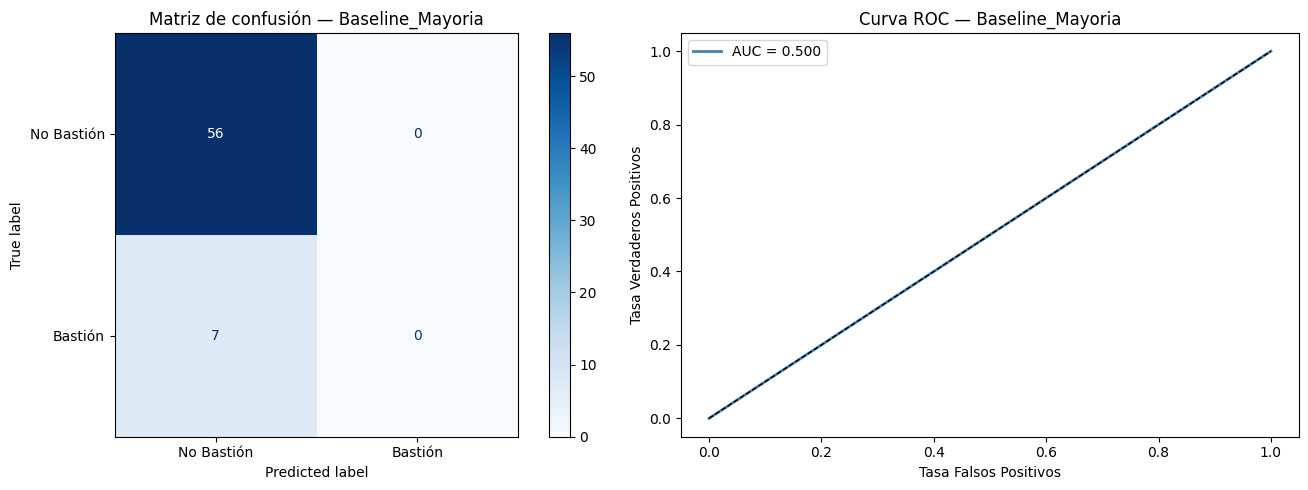

  [SHAP] Omitido para Baseline_Mayoria (costo computacional elevado).
  💾 Checkpoint guardado → modelo_Baseline_Mayoria.pkl

════════════════════════════════════════════════════════════════════════
  Baseline_Estrat
════════════════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

  No Bastión       0.93      0.89      0.91        56
     Bastión       0.33      0.43      0.38         7

    accuracy                           0.84        63
   macro avg       0.63      0.66      0.64        63
weighted avg       0.86      0.84      0.85        63



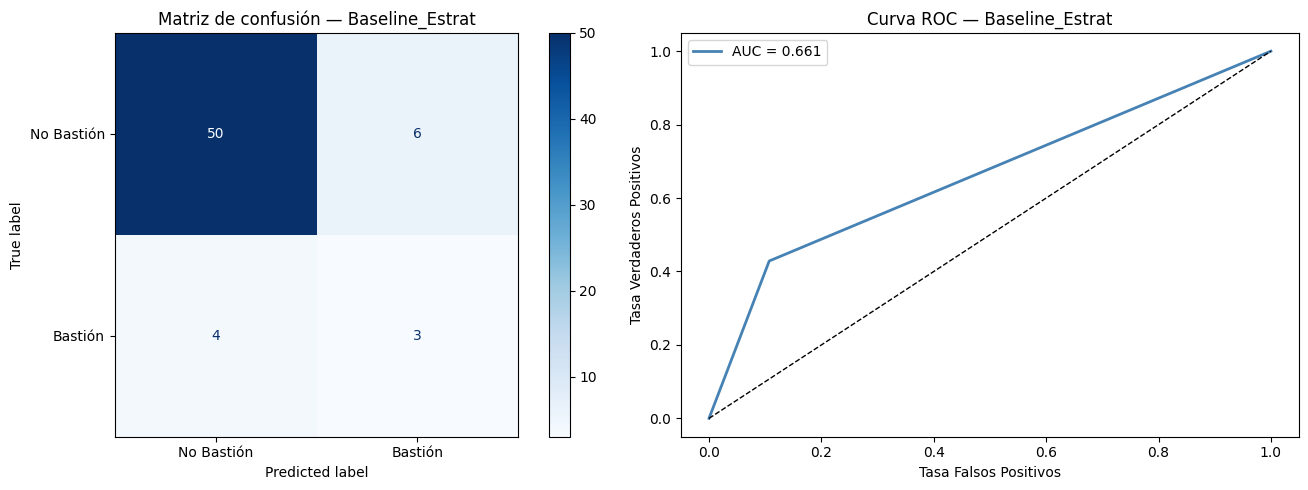

  [SHAP] Omitido para Baseline_Estrat (costo computacional elevado).
  💾 Checkpoint guardado → modelo_Baseline_Estrat.pkl

════════════════════════════════════════════════════════════════════════
  DecisionTree
════════════════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

  No Bastión       0.97      1.00      0.98        56
     Bastión       1.00      0.71      0.83         7

    accuracy                           0.97        63
   macro avg       0.98      0.86      0.91        63
weighted avg       0.97      0.97      0.97        63



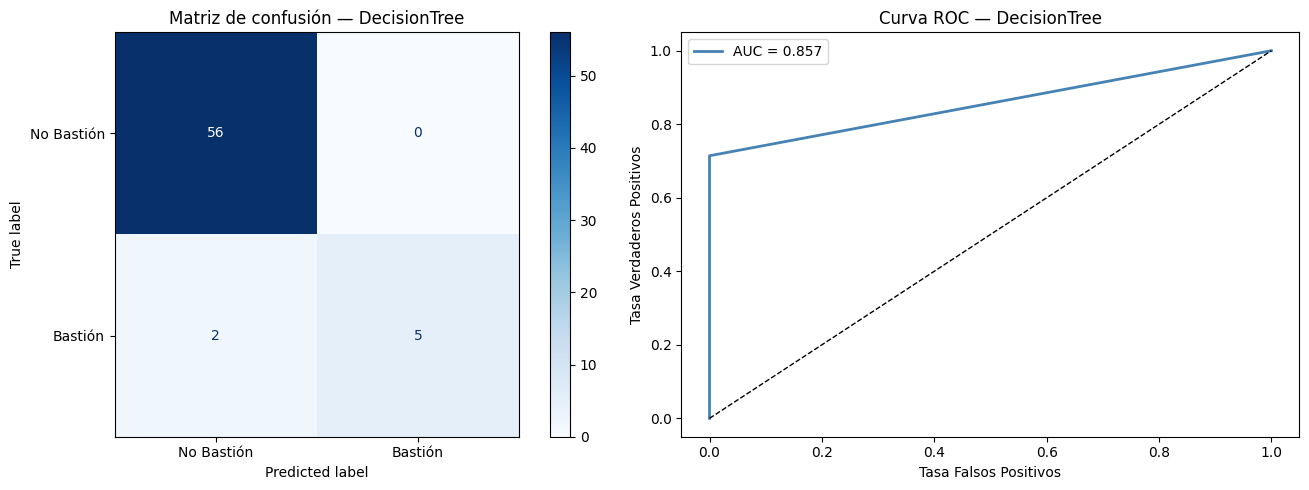

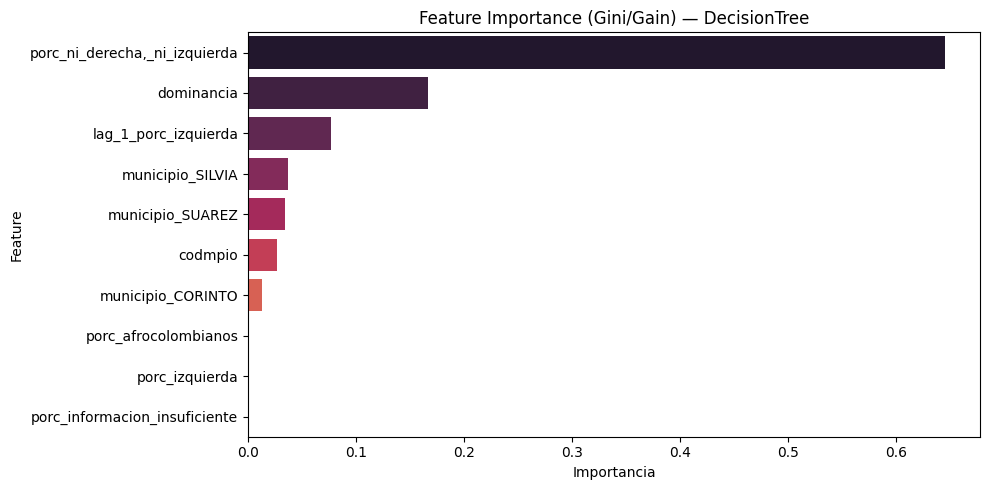

  [PDP] No disponible para DecisionTree: cannot reshape array of size 1 into shape (2)


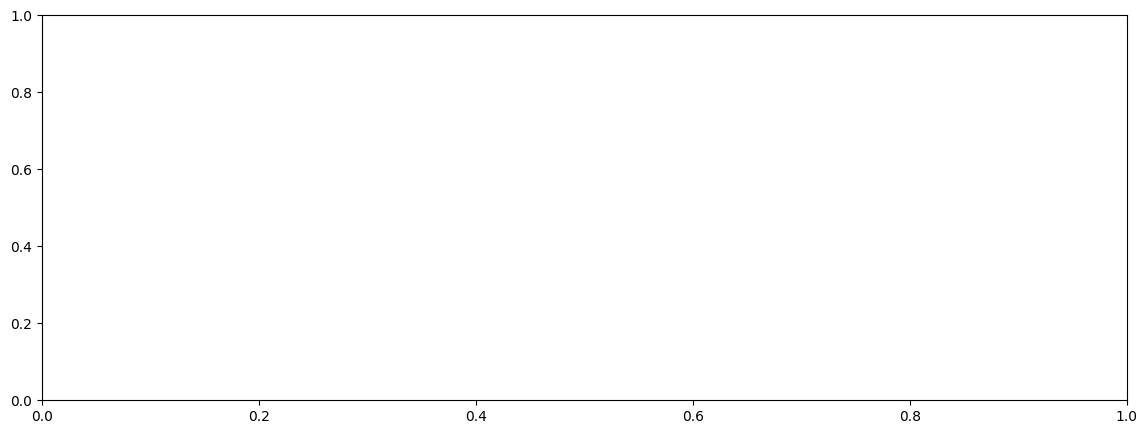

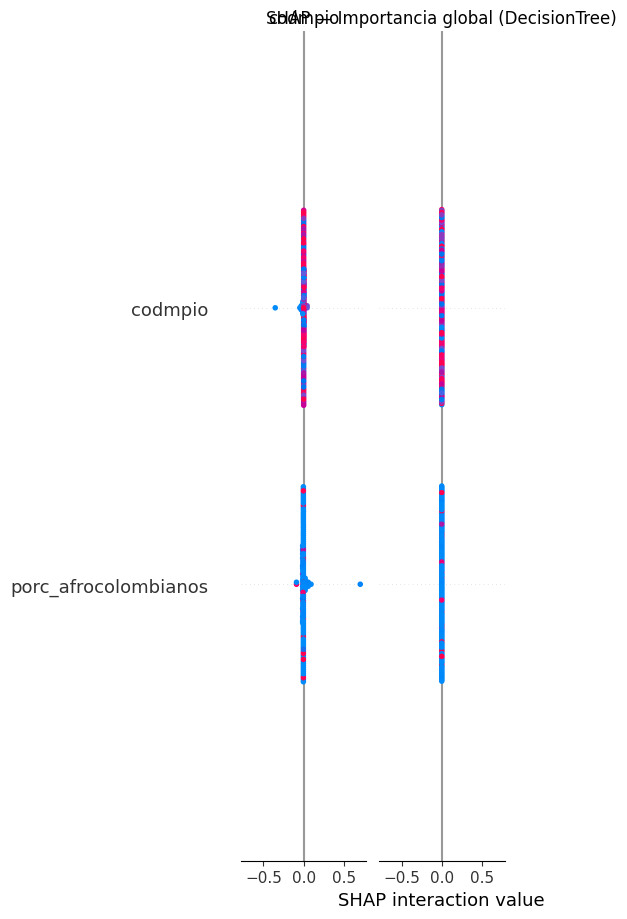

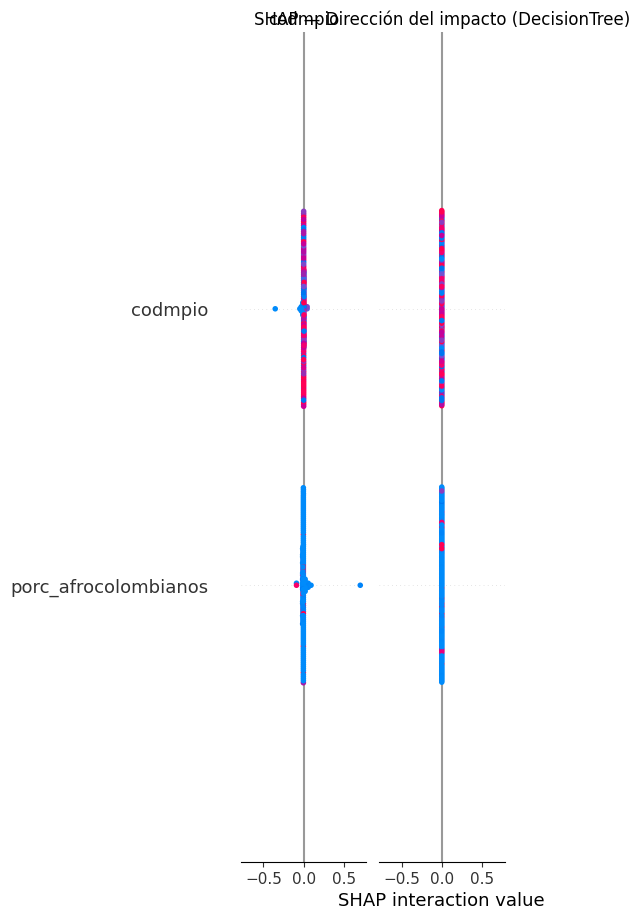

  💾 Checkpoint guardado → modelo_DecisionTree.pkl

════════════════════════════════════════════════════════════════════════
  RandomForest
════════════════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

  No Bastión       0.98      0.98      0.98        56
     Bastión       0.86      0.86      0.86         7

    accuracy                           0.97        63
   macro avg       0.92      0.92      0.92        63
weighted avg       0.97      0.97      0.97        63



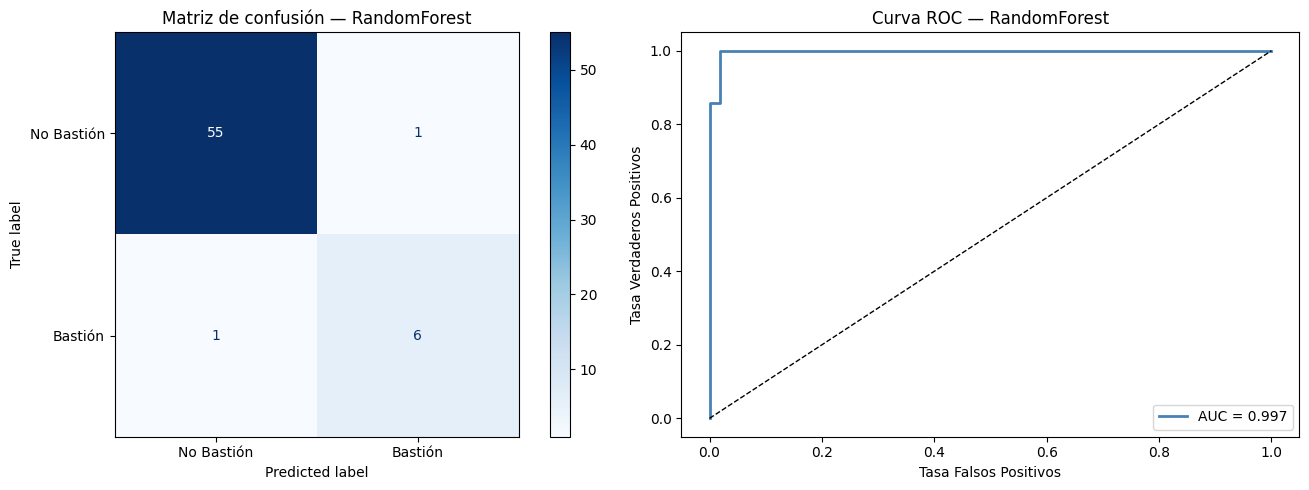

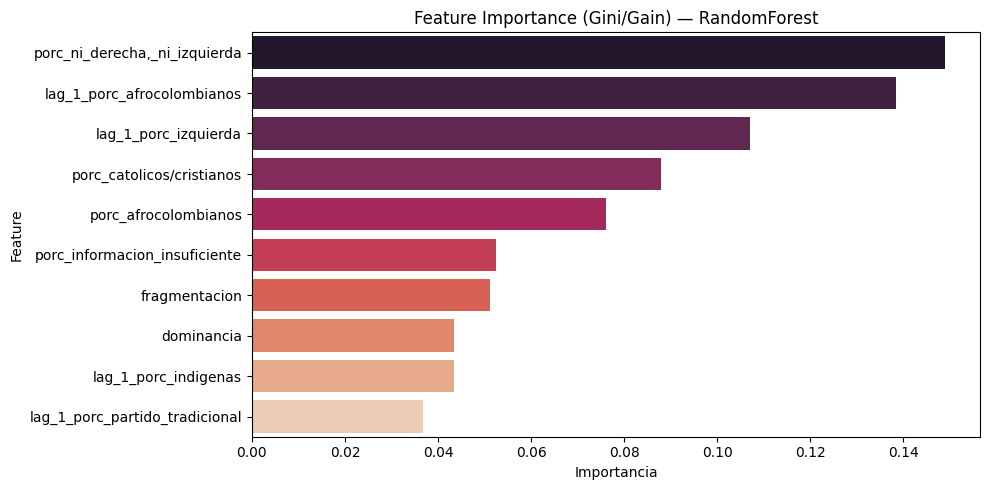

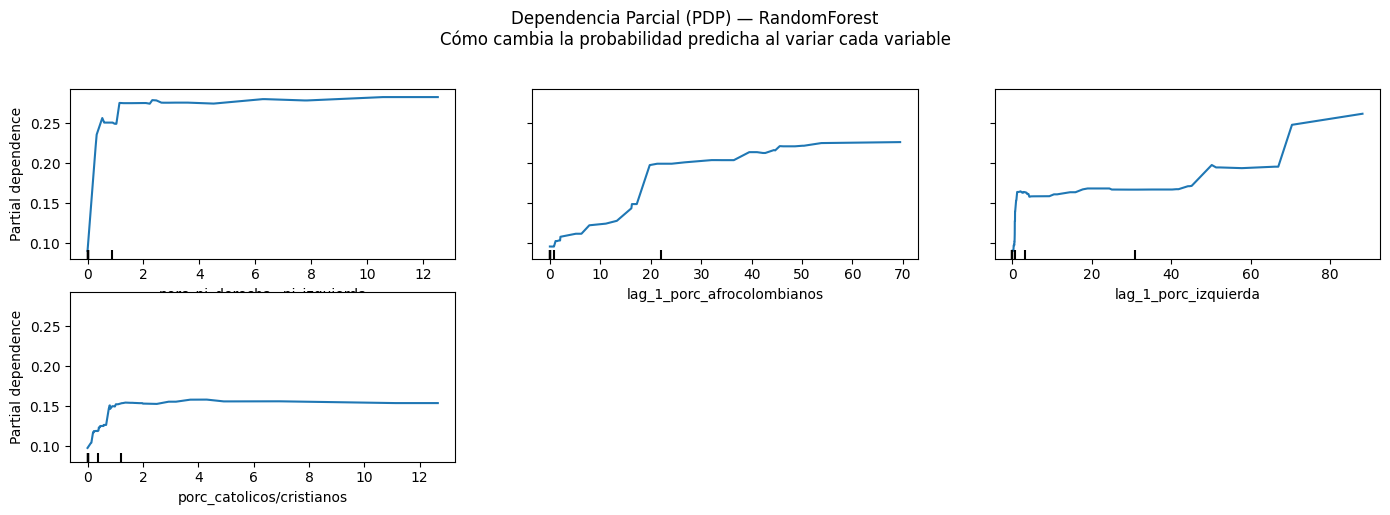

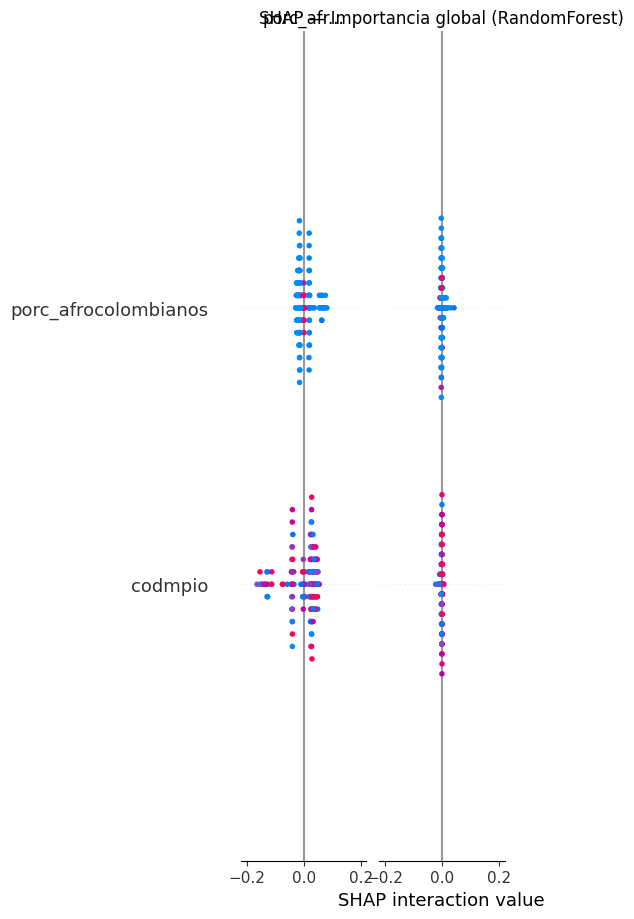

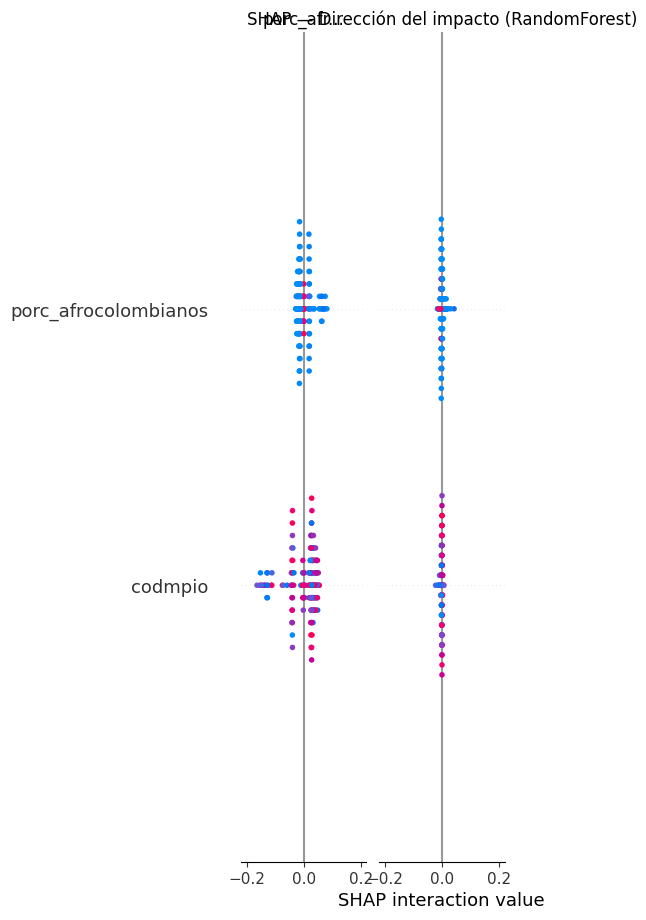

  💾 Checkpoint guardado → modelo_RandomForest.pkl

════════════════════════════════════════════════════════════════════════
  XGBoost
════════════════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

  No Bastión       0.97      1.00      0.98        56
     Bastión       1.00      0.71      0.83         7

    accuracy                           0.97        63
   macro avg       0.98      0.86      0.91        63
weighted avg       0.97      0.97      0.97        63



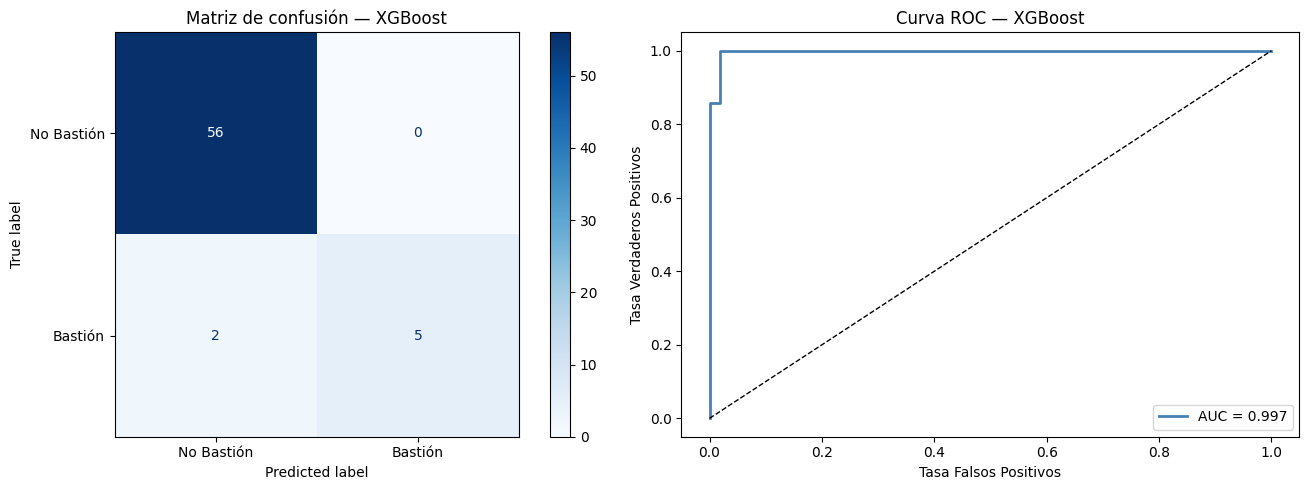

  [SHAP] Error en XGBoost: Model type not yet supported by TreeExplainer: <class 'imblearn.pipeline.Pipeline'>
  💾 Checkpoint guardado → modelo_XGBoost.pkl

════════════════════════════════════════════════════════════════════════
  LogReg
════════════════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

  No Bastión       1.00      0.98      0.99        56
     Bastión       0.88      1.00      0.93         7

    accuracy                           0.98        63
   macro avg       0.94      0.99      0.96        63
weighted avg       0.99      0.98      0.98        63



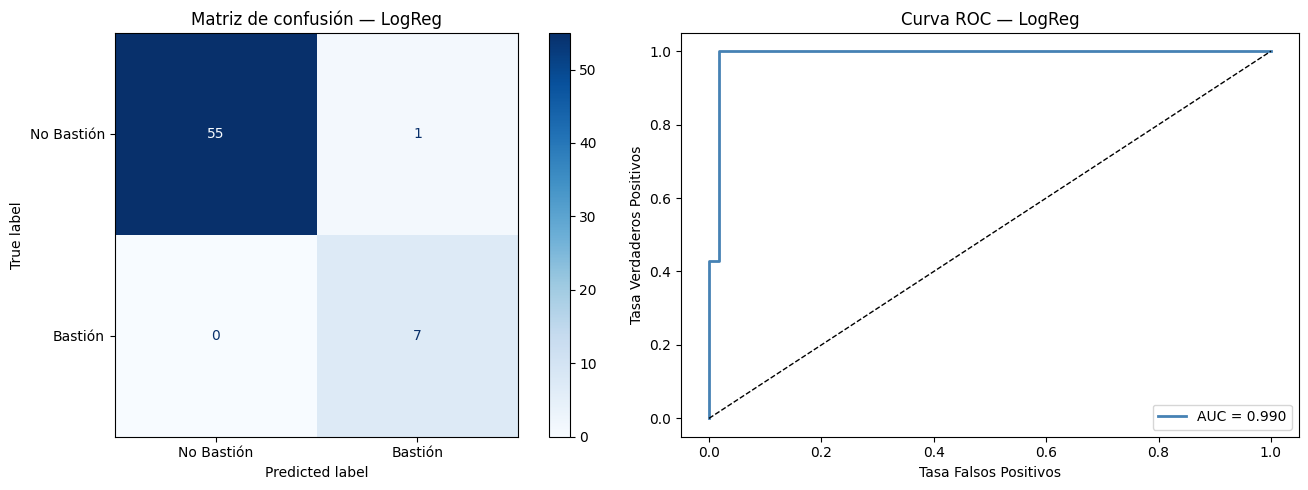

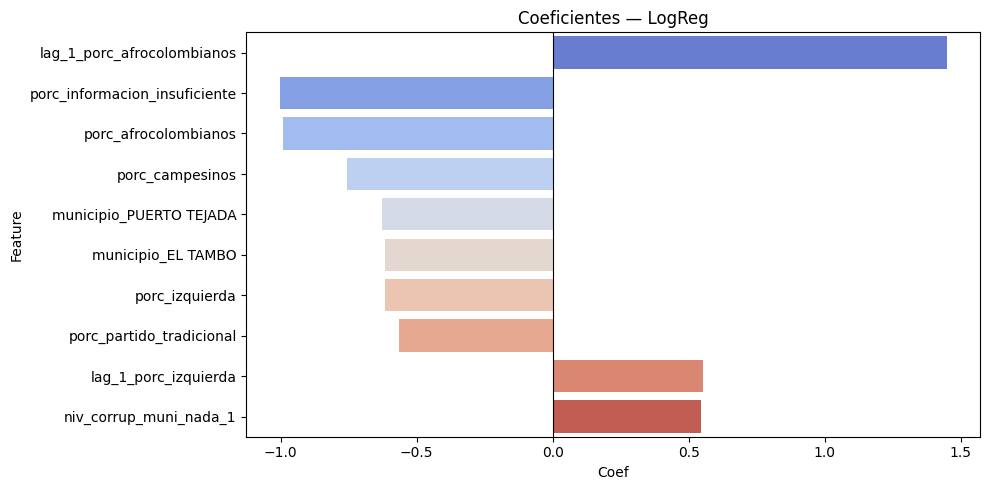

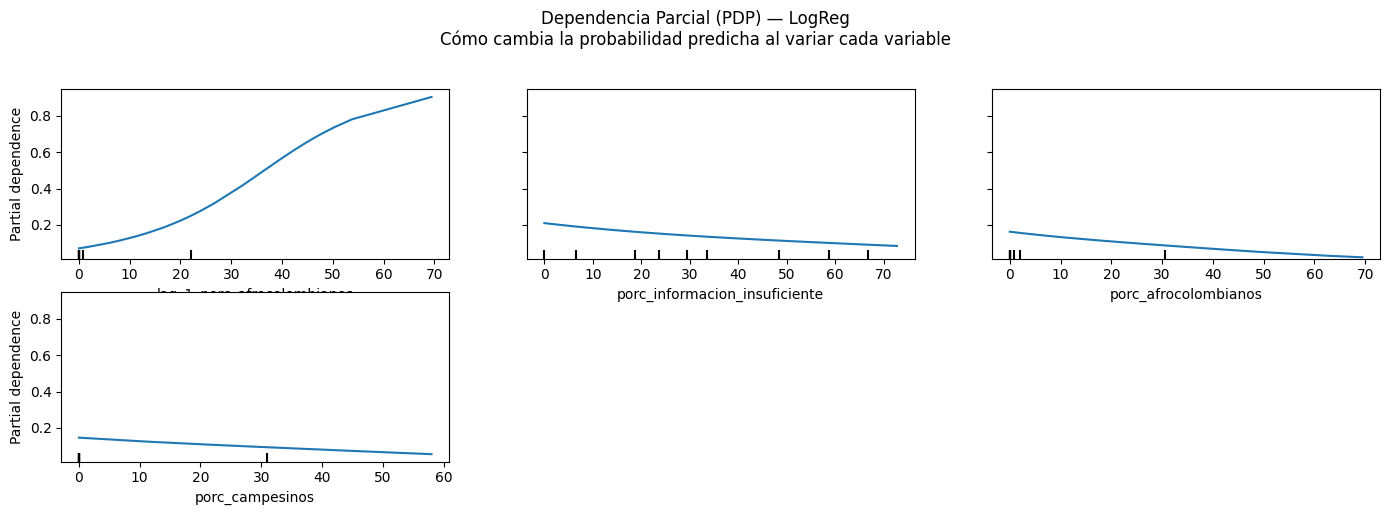

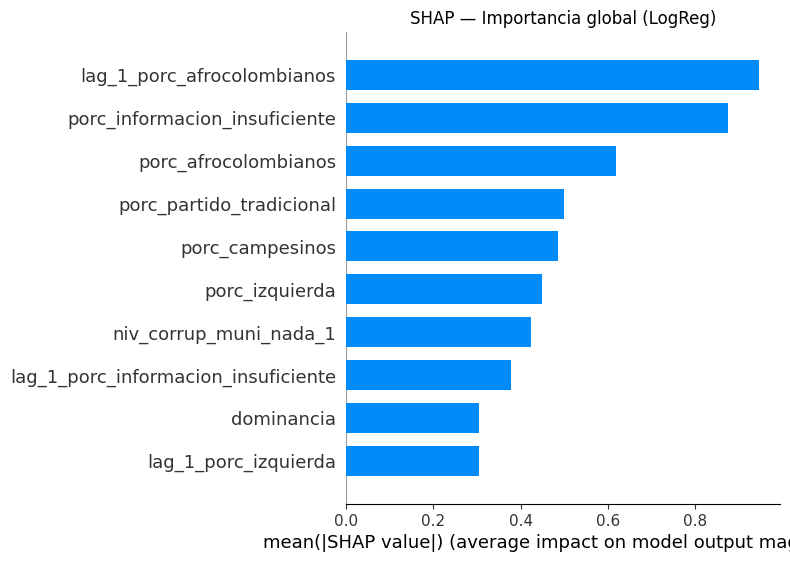

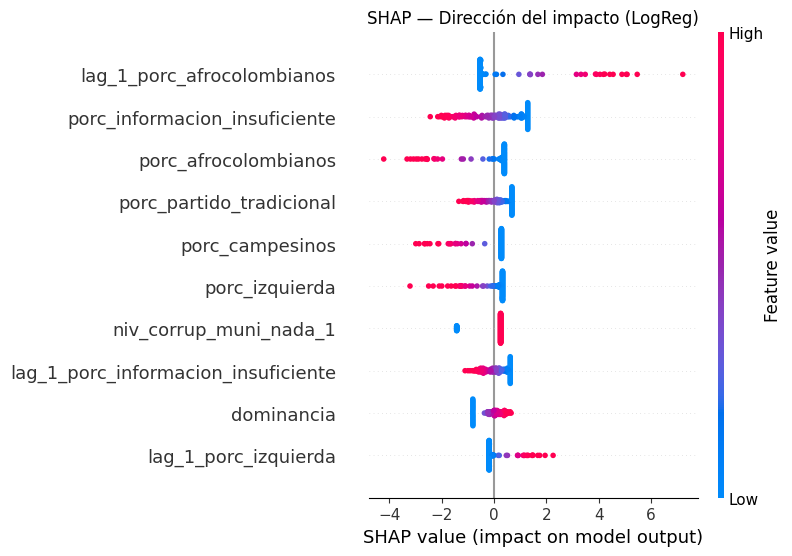

  💾 Checkpoint guardado → modelo_LogReg.pkl

════════════════════════════════════════════════════════════════════════
  NaiveBayes
════════════════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

  No Bastión       0.86      0.64      0.73        56
     Bastión       0.05      0.14      0.07         7

    accuracy                           0.59        63
   macro avg       0.45      0.39      0.40        63
weighted avg       0.77      0.59      0.66        63



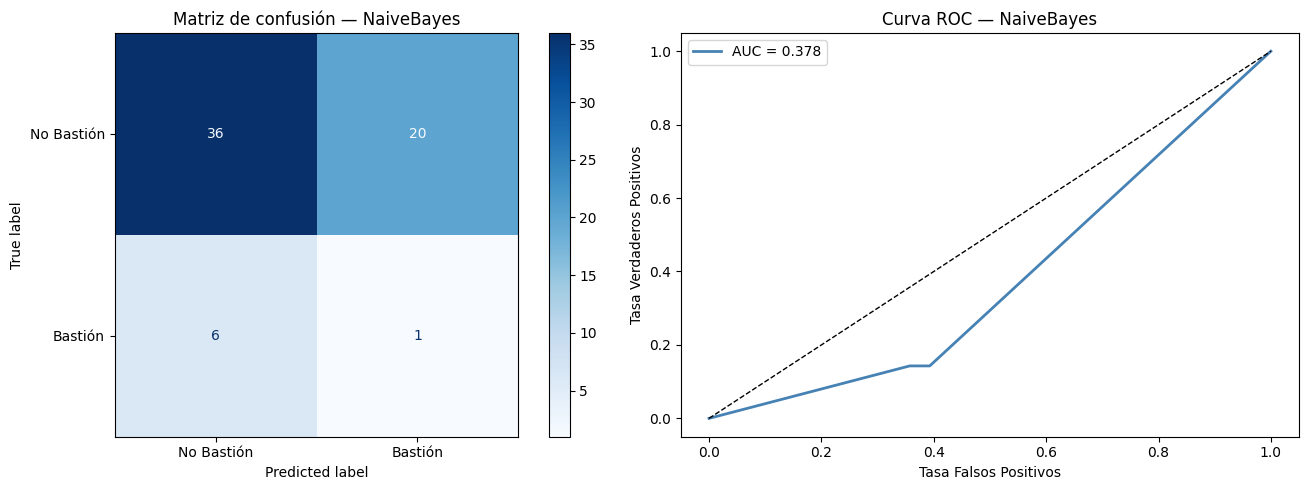

  [SHAP] Omitido para NaiveBayes (costo computacional elevado).
  💾 Checkpoint guardado → modelo_NaiveBayes.pkl

══ Tabla comparativa — test set holdout ══


,Modelo,AUC,F1
0,RandomForest,0.997449,0.968254
1,XGBoost,0.997449,0.965887
2,LogReg,0.989796,0.984585
3,DecisionTree,0.857143,0.965887
4,Baseline_Estrat,0.660714,0.849747
5,Baseline_Mayoria,0.500000,0.836601
6,NaiveBayes,0.377551,0.660998


In [ ]:
# ── Selección del modelo campeón ──────────────────────────────────────────────
# Cambia estos dos valores según la tabla resumen de la Sección 6.
CAMPEON           = 'XGBoost'   # ← modelo con mejor AUC en CV temporal
ESCENARIO_CAMPEON = 'SMOTE'     # ← escenario con mejor AUC para ese modelo

# ── Entrenamiento e interpretabilidad de todos los modelos ────────────────────
modelos_finales  = construir_modelos(SEED)
resultados_finales = []

escenario_dict = dict(ESCENARIOS)

for nombre, modelo_base in modelos_finales.items():
    # El modelo campeón usa el escenario de balanceo elegido.
    # El resto usa Baseline para la comparación final.
    if nombre == CAMPEON:
        sampler = escenario_dict.get(ESCENARIO_CAMPEON)
    else:
        sampler = None

    pipeline = (
        ImbPipeline([('sampler', sampler), ('model', modelo_base)])
        if sampler else modelo_base
    )

    resultado = evaluar_modelo(
        nombre, pipeline,
        X_train_full, y_train_full,
        X_test, y_test
    )
    resultados_finales.append(resultado)
    checkpoint_guardar(pipeline, f'modelo_{nombre}')

# ── Tabla comparativa final ───────────────────────────────────────────────────
df_tabla_final = (
    pd.DataFrame([{'Modelo': r['nombre'], 'AUC': r['auc'], 'F1': r['f1']}
                  for r in resultados_finales])
    .sort_values('AUC', ascending=False)
    .reset_index(drop=True)
)

print('\n══ Tabla comparativa — test set holdout ══')
display(df_tabla_final)

## 9 · Calibración de probabilidades

Calibrando probabilidades del modelo campeón: XGBoost

  ⚡ Checkpoint encontrado → cargando modelo_XGBoost.pkl


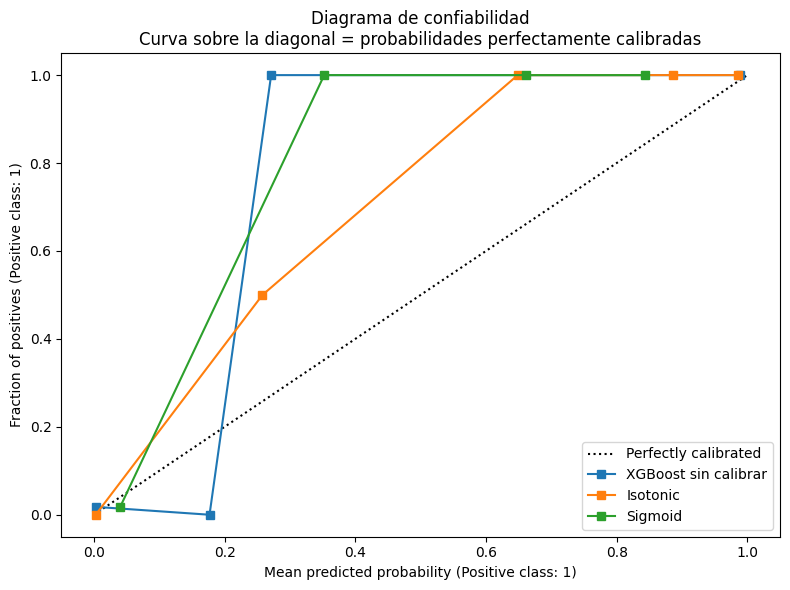

  💾 Checkpoint guardado → modelo_XGBoost_calibrado.pkl

✅ Modelo calibrado guardado.
   Usa este modelo (no el sin calibrar) para reportar probabilidades.


In [ ]:
# ── Calibración de probabilidades ────────────────────────────────────────────
# Un modelo bien calibrado cumple: cuando predice 70% de probabilidad,
# aproximadamente el 70% de esos casos son bastiones en la realidad.
# Esto es crítico para usar las probabilidades en decisiones políticas.

print(f'Calibrando probabilidades del modelo campeón: {CAMPEON}\n')

# Modelo sin calibrar (entrenado en Sección 8)
campeon_sin_cal = checkpoint_cargar(f'modelo_{CAMPEON}')

# Modelos calibrados
campeon_isotonic = CalibratedClassifierCV(
    construir_modelos(SEED)[CAMPEON], method='isotonic', cv=5
)
campeon_sigmoid  = CalibratedClassifierCV(
    construir_modelos(SEED)[CAMPEON], method='sigmoid',  cv=5
)
campeon_isotonic.fit(X_train_full, y_train_full)
campeon_sigmoid.fit(X_train_full,  y_train_full)

# ── Diagrama de confiabilidad ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

CalibrationDisplay.from_estimator(
    campeon_sin_cal,  X_test, y_test, n_bins=10,
    name=f'{CAMPEON} sin calibrar', ax=ax
)
CalibrationDisplay.from_estimator(
    campeon_isotonic, X_test, y_test, n_bins=10,
    name='Isotonic', ax=ax
)
CalibrationDisplay.from_estimator(
    campeon_sigmoid,  X_test, y_test, n_bins=10,
    name='Sigmoid', ax=ax
)

ax.set_title(
    'Diagrama de confiabilidad\n'
    'Curva sobre la diagonal = probabilidades perfectamente calibradas'
)
plt.tight_layout()
plt.show()

# Guardar el modelo calibrado para predicciones finales
checkpoint_guardar(campeon_isotonic, f'modelo_{CAMPEON}_calibrado')

print(f'\n✅ Modelo calibrado guardado.')
print('   Usa este modelo (no el sin calibrar) para reportar probabilidades.')

In [ ]:
# ── SECCIÓN 10 · Predicción final + años de victoria ─────────────────────────
# Esta celda es completamente autónoma: carga, procesa y predice sin depender
# de variables intermedias de sesiones anteriores.

# ── 1. Cargar datos de 2023 ───────────────────────────────────────────────────
df_raw_23  = limpiar_columnas(pd.read_csv(CONFIG['ruta_electoral_23']))
df_mapa_23 = limpiar_columnas(
    pd.read_excel(CONFIG['ruta_mapa_23'])
)[['codigo_partido', 'etiqueta_partido']]

df_23 = pd.merge(df_raw_23, df_mapa_23, on='codigo_partido', how='left')
df_23.rename(columns={'etiqueta_partido': 'etiqueta_final'}, inplace=True)
df_23 = limpiar_columnas(df_23)
df_23.rename(columns={'codigo_municipio': 'codmpio_corto'}, inplace=True)

# ── 2. Cargar datos socioeconómicos para predicción ───────────────────────────
df_socio_pred = limpiar_columnas(pd.read_excel(CONFIG['ruta_socio']))
# Unificar nombre de la llave municipal
for col_cand in ['cod_municipio', 'codmpio', 'codigo_municipio', 'cod_mpio']:
    if col_cand in df_socio_pred.columns:
        df_socio_pred.rename(columns={col_cand: 'codmpio'}, inplace=True)
        break
df_socio_pred['codmpio'] = pd.to_numeric(df_socio_pred['codmpio'], errors='coerce')
print(f"df_socio_pred: {df_socio_pred.shape} | "
      f"Municipios: {df_socio_pred['codmpio'].nunique()}")

# ── 3. Traducir código corto → DANE usando nombre_municipio como puente ───────
# df_23 tiene códigos cortos (1, 4, 5...) pero el datamart usa DANE (19001...)
ALIASES = {
    'LOPEZ (MICAY)'     : 'LOPEZ DE MICAY',
    'PAEZ (BELALCAZAR)' : 'PAEZ',
    'PURACE (COCONUCO)' : 'PURACE',
    'SOTARA (PAISPAMBA)': 'SOTARA',
}

mapa_dane = (df_entrenamiento[['codmpio', 'municipio']]
             .drop_duplicates()
             .assign(municipio_key=lambda d: d['municipio'].str.upper().str.strip()))

df_23['municipio_key'] = (df_23['nombre_municipio']
                          .str.upper().str.strip()
                          .replace(ALIASES))

df_23 = pd.merge(
    df_23,
    mapa_dane[['municipio_key', 'codmpio']].rename(columns={'codmpio': 'codmpio_dane'}),
    on='municipio_key', how='left'
)
df_23['codmpio'] = df_23['codmpio_dane']
df_23.drop(columns=['codmpio_corto', 'codmpio_dane', 'municipio_key'],
           inplace=True, errors='ignore')

n_sin = df_23['codmpio'].isna().sum()
print(f"Filas sin DANE tras corrección de aliases: {n_sin} "
      f"({'✅ ninguna' if n_sin == 0 else '⚠️ revisar'})")
print(f"Municipios únicos con DANE: {df_23['codmpio'].nunique()}")

# ── 4. Agregar a nivel municipio ──────────────────────────────────────────────
# df_23 está a nivel puesto/mesa. Necesitamos una fila por municipio
# con los porcentajes de voto por etiqueta, igual que el datamart de entrenamiento.
df_23_gob = df_23[
    (df_23['nombre_corporacion'].str.upper() == 'GOBERNADOR') &
    (~df_23['etiqueta_final'].isin([
        'BLANCOS/NULOS/NO MARCADOS', 'INFORMACIÓN INSUFICIENTE',
        'INFORMACION INSUFICIENTE'
    ])) &
    (df_23['etiqueta_final'].notna())
].copy()

votos_etiqueta = (df_23_gob
    .groupby(['codmpio', 'nombre_municipio', 'etiqueta_final'])['total_votos']
    .sum().reset_index())
votos_totales  = (df_23_gob
    .groupby('codmpio')['total_votos']
    .sum().reset_index()
    .rename(columns={'total_votos': 'votos_totales'}))

df_porc_23 = pd.merge(votos_etiqueta, votos_totales, on='codmpio')
df_porc_23['porc'] = df_porc_23['total_votos'] / df_porc_23['votos_totales'] * 100

df_23_muni = (df_porc_23
    .pivot_table(index=['codmpio', 'nombre_municipio'],
                 columns='etiqueta_final',
                 values='porc', fill_value=0)
    .reset_index())

df_23_muni.columns = (
    ['codmpio', 'nombre_municipio'] +
    [f"porc_{c.lower().replace(' ', '_').replace('/', '_')}"
     for c in df_23_muni.columns if c not in ['codmpio', 'nombre_municipio']]
)
df_23_muni = df_23_muni.drop_duplicates(subset='codmpio', keep='first')
print(f"\ndf_23_muni: {df_23_muni.shape} — 1 fila por municipio ✅")

# ── 5. Extraer lag 2019 desde el datamart ────────────────────────────────────
df_2019_lag_local = df_entrenamiento[df_entrenamiento['ano'] == 2019].copy()
cols_lag = ['codmpio'] + [
    c for c in df_2019_lag_local.columns
    if c.startswith('porc_') or c in ['fragmentacion', 'dominancia']
]
df_2019_lag_local = df_2019_lag_local[cols_lag].copy()
df_2019_lag_local.columns = (
    ['codmpio'] +
    [f"lag_19_{c.replace('porc_', '')}"
     for c in df_2019_lag_local.columns if c != 'codmpio']
)
print(f"Lag 2019: {df_2019_lag_local.shape}")

# ── 6. Ensamble ───────────────────────────────────────────────────────────────
df_pred = pd.merge(df_23_muni,        df_2019_lag_local, on='codmpio', how='left')
df_pred = pd.merge(df_pred,           df_socio_pred,     on='codmpio', how='left')
df_pred = imputar_con_media_municipal(df_pred)

# Validar que los joins funcionaron
lag_cols   = [c for c in df_pred.columns if c.startswith('lag_19_')]
n_lag_ok   = df_pred[lag_cols].notna().all(axis=1).sum()
n_socio_ok = (df_pred['porcentaje_indigena'].notna().sum()
              if 'porcentaje_indigena' in df_pred.columns else 0)
print(f"Municipios con lag 2019 completo   : {n_lag_ok} / {len(df_pred)}")
print(f"Municipios con datos socio completo: {n_socio_ok} / {len(df_pred)}")

# ── 7. Alinear feature set con el entrenamiento ───────────────────────────────
COLS_META    = ['codmpio', 'nombre_municipio']
df_meta      = df_pred[COLS_META].copy().reset_index(drop=True)

df_pred_feat = pd.get_dummies(
    df_pred.drop(columns=COLS_META, errors='ignore'),
    drop_first=True, dtype=int
)
df_pred_feat = df_pred_feat.reindex(
    columns=X_train_full.columns, fill_value=0
)

cols_faltantes = set(X_train_full.columns) - set(df_pred_feat.columns)
print(f"\n{'✅' if not cols_faltantes else '⚠️ '} Feature set: "
      f"{df_pred_feat.shape[1]} columnas | Faltantes: {len(cols_faltantes)}")

# ── 8. Predicción con modelo calibrado ───────────────────────────────────────
modelo_cal = checkpoint_cargar(f'modelo_{CAMPEON}_calibrado')
prob_pred  = modelo_cal.predict_proba(df_pred_feat)[:, 1] * 100
clase_pred = (prob_pred >= UMBRAL).astype(int)

# ── 9. Años de victoria históricos ───────────────────────────────────────────
# Para cada municipio: en qué años históricos superó el umbral étnico.
df_hist_gob = df_entrenamiento[
    df_entrenamiento['tipo_eleccion'] == CONFIG['TIPO_ELECCION']
].copy()
df_hist_gob['fue_bastion'] = (
    df_hist_gob[CONFIG['TARGET_COL']] >= UMBRAL
).astype(int)

anos_victoria = (df_hist_gob[df_hist_gob['fue_bastion'] == 1]
                 .groupby('codmpio')['ano']
                 .apply(lambda x: sorted([int(a) for a in x.unique()]))
                 .reset_index()
                 .rename(columns={'ano': 'anos_lista'}))

anos_victoria['n_victorias']    = anos_victoria['anos_lista'].apply(len)
anos_victoria['primer_bastion'] = anos_victoria['anos_lista'].apply(min)
anos_victoria['ultimo_bastion'] = anos_victoria['anos_lista'].apply(max)
anos_victoria['anos_victoria']  = anos_victoria['anos_lista'].apply(
    lambda x: ', '.join(map(str, x))
)
anos_victoria.drop(columns=['anos_lista'], inplace=True)

# ── 10. Construir tabla de resultados ─────────────────────────────────────────
df_resultados = df_meta.copy()
df_resultados['prob_bastion_%'] = prob_pred.round(1)
df_resultados['pred_bastion']   = clase_pred

df_resultados = pd.merge(df_resultados, anos_victoria, on='codmpio', how='left')
df_resultados['anos_victoria']  = df_resultados['anos_victoria'].fillna('Nunca')
df_resultados['n_victorias']    = df_resultados['n_victorias'].fillna(0).astype(int)
df_resultados['primer_bastion'] = df_resultados['primer_bastion'].fillna('-')
df_resultados['ultimo_bastion'] = df_resultados['ultimo_bastion'].fillna('-')

# Completar nombres faltantes para los 4 municipios con alias
if df_resultados['nombre_municipio'].isna().any():
    df_resultados = pd.merge(
        df_resultados,
        mapa_dane[['codmpio', 'municipio']],
        on='codmpio', how='left'
    )
    df_resultados['nombre_municipio'] = (
        df_resultados['nombre_municipio'].fillna(df_resultados['municipio'])
    )
    df_resultados.drop(columns=['municipio'], inplace=True, errors='ignore')

# ── 11. Exportar ──────────────────────────────────────────────────────────────
ruta_salida = os.path.join(
    BASE_DIR, f'predicciones_cauca_2023_{CAMPEON}.csv'
)
df_resultados.to_csv(ruta_salida, index=False, encoding='utf-8-sig')

# ── 12. Resumen y visualización ───────────────────────────────────────────────
print(f'''
✅ Predicciones exportadas → {ruta_salida}

── Resumen ──────────────────────────────────────────────────
  Total municipios          : {len(df_resultados)}
  Bastiones predichos 2023  : {df_resultados['pred_bastion'].sum()}
  Con historial bastión     : {(df_resultados['n_victorias'] > 0).sum()}
  Bastión predicho + historial (consolidados) : {((df_resultados['pred_bastion']==1) & (df_resultados['n_victorias']>0)).sum()}
  Bastión predicho sin historial (emergentes) : {((df_resultados['pred_bastion']==1) & (df_resultados['n_victorias']==0)).sum()}
  Con historial pero NO predicho (erosión)    : {((df_resultados['pred_bastion']==0) & (df_resultados['n_victorias']>0)).sum()}
''')

print('── Top 10 por probabilidad ──')
display(
    df_resultados
    [['nombre_municipio', 'prob_bastion_%', 'pred_bastion',
      'n_victorias', 'primer_bastion', 'ultimo_bastion', 'anos_victoria']]
    .sort_values('prob_bastion_%', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

print('\n── Bastiones predichos con historial completo ──')
display(
    df_resultados[df_resultados['pred_bastion'] == 1]
    [['nombre_municipio', 'prob_bastion_%',
      'n_victorias', 'primer_bastion', 'ultimo_bastion', 'anos_victoria']]
    .sort_values(['n_victorias', 'prob_bastion_%'], ascending=[False, False])
    .reset_index(drop=True)
)


df_socio_pred: (42, 197) | Municipios: 42
Filas sin DANE tras corrección de aliases: 0 (✅ ninguna)
Municipios únicos con DANE: 42

df_23_muni: (42, 5) — 1 fila por municipio ✅
Lag 2019: (124, 14)
Municipios con lag 2019 completo   : 124 / 124
Municipios con datos socio completo: 124 / 124

✅ Feature set: 72 columnas | Faltantes: 0
  ⚡ Checkpoint encontrado → cargando modelo_XGBoost_calibrado.pkl

✅ Predicciones exportadas → /content/drive/My Drive/Documentos varios/MAIN/3er Semestre/predicciones_cauca_2023_XGBoost.csv

── Resumen ──────────────────────────────────────────────────
  Total municipios          : 124
  Bastiones predichos 2023  : 0
  Con historial bastión     : 96
  Bastión predicho + historial (consolidados) : 0
  Bastión predicho sin historial (emergentes) : 0
  Con historial pero NO predicho (erosión)    : 96

── Top 10 por probabilidad ──


,nombre_municipio,prob_bastion_%,pred_bastion,n_victorias,primer_bastion,ultimo_bastion,anos_victoria
0,LA VEGA,27.8,0,1,2011.0,2011.0,2011
1,LA VEGA,27.8,0,1,2011.0,2011.0,2011
2,JAMBALO,27.8,0,2,2007.0,2011.0,"2007, 2011"
3,LA VEGA,27.8,0,1,2011.0,2011.0,2011
4,JAMBALO,27.8,0,2,2007.0,2011.0,"2007, 2011"
5,JAMBALO,27.8,0,2,2007.0,2011.0,"2007, 2011"
6,TOTORO,27.8,0,1,2011.0,2011.0,2011
7,TOTORO,27.8,0,1,2011.0,2011.0,2011
8,TOTORO,27.8,0,1,2011.0,2011.0,2011
9,ALMAGUER,26.6,0,1,2011.0,2011.0,2011



── Bastiones predichos con historial completo ──


,nombre_municipio,prob_bastion_%,n_victorias,primer_bastion,ultimo_bastion,anos_victoria


## 11 · Visualización interactiva y mapas coropléticos

> **Gráfico A** — Barras por municipio: probabilidad de bastión 2023.  
> **Gráfico B** — Barras por puesto de votación: voto indígena dentro del municipio seleccionado.  
> **Panel C** — Mapas coropléticos: bastión / no bastión para cada año de validación + predicción 2023.  

> Cambia `MUNICIPIO_VIZ` al inicio de la celda de código para explorar otro municipio.

Generando gráfico A: probabilidades por municipio...



Generando gráfico B: probabilidades por puesto en CALDONO...


  Puestos sobre el umbral: 8 / 11

Generando panel de mapas coropléticos...


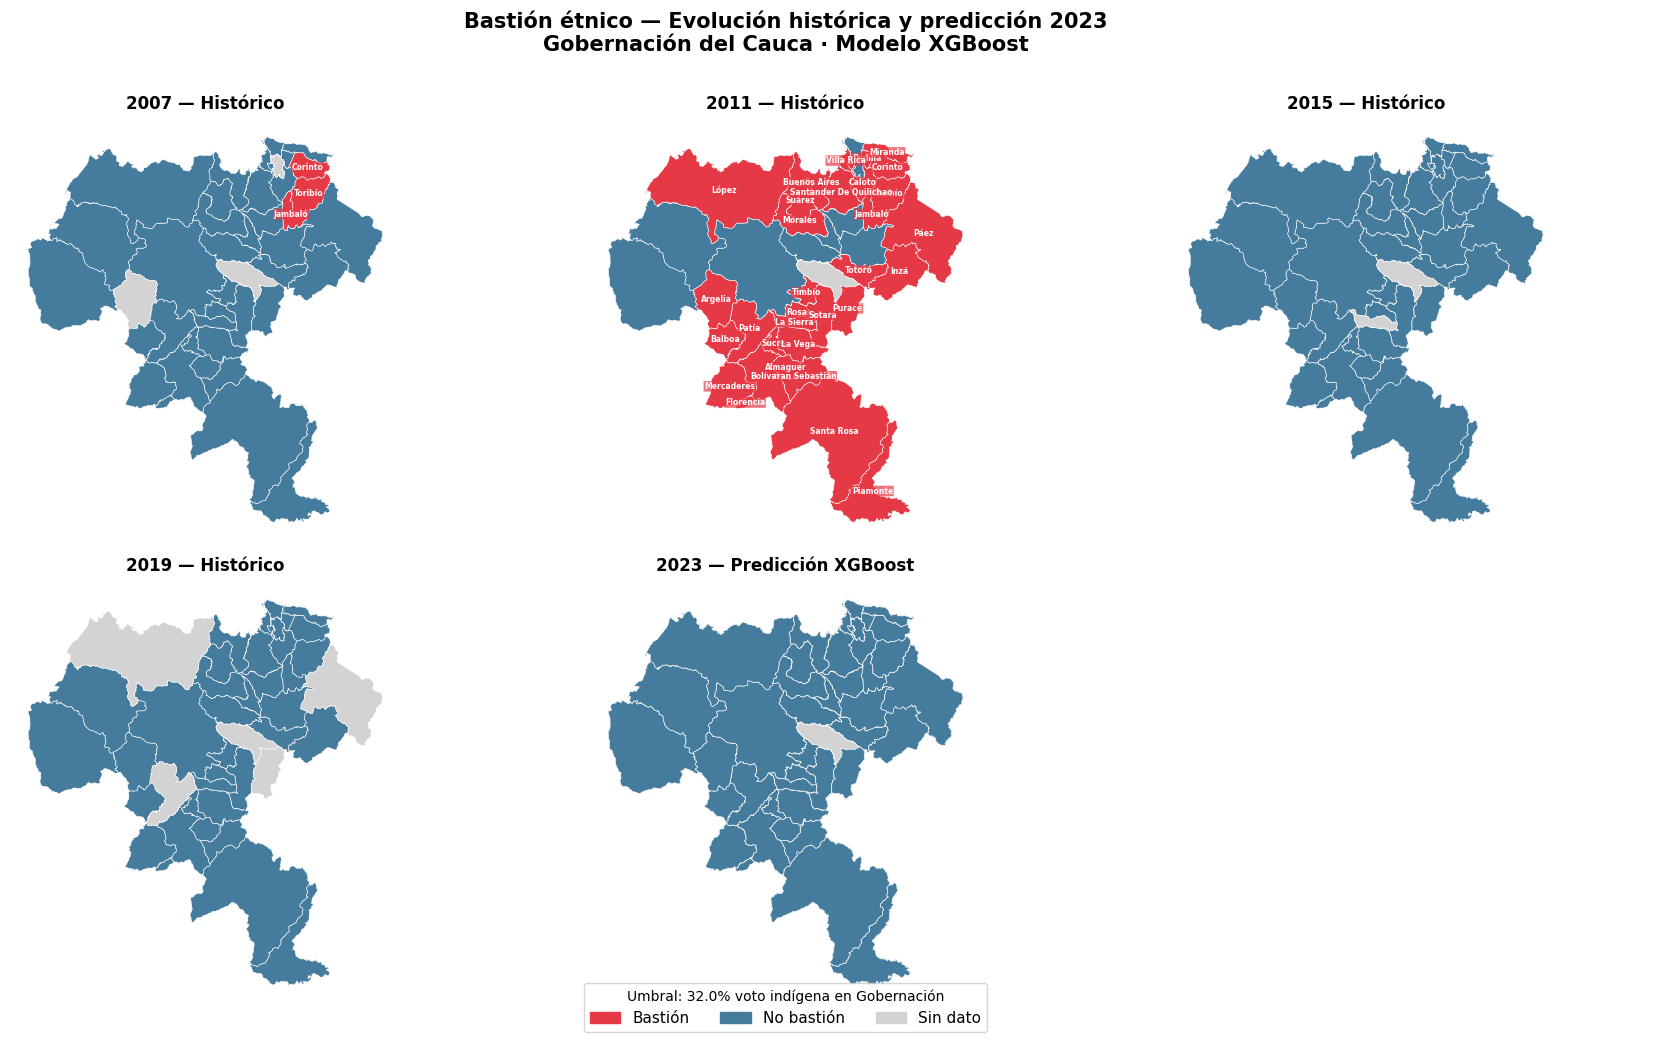


✅ Mapa guardado → /content/drive/My Drive/Documentos varios/MAIN/3er Semestre/mapa_bastion_evolucion_XGBoost.png

── Cómo cambiar el municipio visualizado ───────────────────────────────
   Modifica MUNICIPIO_VIZ al inicio de esta celda.
   Municipios disponibles:
   ALMAGUER | ARGELIA | BALBOA | BOLIVAR | BUENOS AIRES | CAJIBIO | CALDONO | CALOTO | CORINTO | EL TAMBO | FLORENCIA | GUACHENE | GUAPI | INZA | JAMBALO | LA SIERRA | LA VEGA | LOPEZ (MICAY) | MERCADERES | MIRANDA | MORALES | PADILLA | PAEZ (BELALCAZAR) | PATIA (EL BORDO) | PIAMONTE | PIENDAMO | POPAYAN | PUERTO TEJADA | PURACE (COCONUCO) | ROSAS | SAN SEBASTIAN | SANTA ROSA | SANTANDER DE QUILICHAO | SILVIA | SOTARA (PAISPAMBA) | SUAREZ | SUCRE | TIMBIO | TIMBIQUI | TORIBIO | TOTORO | VILLA RICA


In [ ]:
# ── SECCIÓN 11 · Visualización interactiva + Mapas coropléticos ──────────────
#
# Esta celda produce tres instrumentos visuales:
#   A. Gráfico de barras interactivo por municipio (probabilidad de bastión 2023)
#   B. Gráfico de barras interactivo por puesto de votación (dentro de cada municipio)
#   C. Panel de mapas coropléticos — Bastión / No Bastión para cada año de validación
#
# Requisitos previos: haber ejecutado la celda 10 (df_resultados, df_23_gob, df_entrenamiento)
# y tener el shapefile de municipios en CONFIG['ruta_municipios_geo'] (Sección 1).

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import geopandas as gpd
import json as _json
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────────────────────
# PARÁMETRO DE CONTROL — cambia este valor para explorar un municipio distinto
# ─────────────────────────────────────────────────────────────────────────────
MUNICIPIO_VIZ = 'CALDONO'   # ← nombre en mayúsculas, sin tildes

# Ruta al shapefile de municipios (debe estar en tu Drive)
RUTA_SHP_MUNICIPIOS = os.path.join(
    BASE_DIR,
    'Nuevo dataset/Shape_Cauca/Cauca_municipios.shp'
)
COL_DANE_SHP = 'Cod_dane'   # columna con código DANE en el shapefile

# ─────────────────────────────────────────────────────────────────────────────
# A. GRÁFICO INTERACTIVO — PROBABILIDAD POR MUNICIPIO (2023)
# ─────────────────────────────────────────────────────────────────────────────
print("Generando gráfico A: probabilidades por municipio...")

df_plot_muni = df_resultados.copy().sort_values('prob_bastion_%', ascending=False)
df_plot_muni['color_barra'] = df_plot_muni['pred_bastion'].map(
    {1: '#e63946', 0: '#457b9d'}
)
df_plot_muni['etiqueta_hover'] = (
    df_plot_muni['nombre_municipio'] + '<br>' +
    'Prob. bastión: ' + df_plot_muni['prob_bastion_%'].astype(str) + '%<br>' +
    'Victorias históricas: ' + df_plot_muni['n_victorias'].astype(str) + '<br>' +
    'Años: ' + df_plot_muni['anos_victoria']
)

fig_muni = go.Figure()
fig_muni.add_trace(go.Bar(
    x=df_plot_muni['nombre_municipio'],
    y=df_plot_muni['prob_bastion_%'],
    marker_color=df_plot_muni['color_barra'],
    text=df_plot_muni['prob_bastion_%'].astype(str) + '%',
    textposition='outside',
    hovertext=df_plot_muni['etiqueta_hover'],
    hoverinfo='text',
    name='Probabilidad de bastión',
))

fig_muni.add_hline(
    y=UMBRAL,
    line_dash='dash',
    line_color='gray',
    annotation_text=f'Umbral de bastión ({UMBRAL}%)',
    annotation_position='top right',
)

fig_muni.update_layout(
    title=dict(
        text=f'Probabilidad de bastión étnico por municipio — Cauca 2023<br>'
             f'<sup>Modelo: {CAMPEON} | Umbral: {UMBRAL}% | '
             f'Rojo = bastión predicho · Azul = no bastión</sup>',
        font_size=14
    ),
    xaxis=dict(
        title='Municipio',
        tickangle=-45,
        tickfont_size=10,
    ),
    yaxis=dict(title='Probabilidad de bastión (%)', range=[0, 105]),
    height=520,
    showlegend=False,
    plot_bgcolor='white',
    paper_bgcolor='white',
)
fig_muni.show()

# ─────────────────────────────────────────────────────────────────────────────
# B. GRÁFICO INTERACTIVO — PROBABILIDAD POR PUESTO DE VOTACIÓN
#    Requiere df_23_gob (generado en la celda 10) y el modelo calibrado
# ─────────────────────────────────────────────────────────────────────────────
print(f"\nGenerando gráfico B: probabilidades por puesto en {MUNICIPIO_VIZ}...")

# Verificar que el municipio existe
municipios_disponibles = (df_resultados['nombre_municipio']
                          .str.upper().str.strip().unique())
if MUNICIPIO_VIZ.upper().strip() not in municipios_disponibles:
    print(f"  ⚠️  '{MUNICIPIO_VIZ}' no encontrado. Municipios disponibles:")
    print( "  " + ", ".join(sorted(municipios_disponibles)))
else:
    # Obtener el codmpio del municipio seleccionado
    codmpio_viz = df_resultados.loc[
        df_resultados['nombre_municipio'].str.upper().str.strip() == MUNICIPIO_VIZ.upper().strip(),
        'codmpio'
    ].values[0]

    # Calcular porcentaje de voto indígena por puesto en 2023
    df_puestos_muni = df_23_gob[
        df_23_gob['codmpio'] == codmpio_viz
    ].copy()

    if df_puestos_muni.empty:
        print(f"  ⚠️  Sin datos de puestos para {MUNICIPIO_VIZ}")
    else:
        votos_ind_puesto = (
            df_puestos_muni[df_puestos_muni['etiqueta_final'] == 'INDÍGENAS']
            .groupby(['codigo_puesto', 'nombre_puesto'])['total_votos']
            .sum().reset_index()
            .rename(columns={'total_votos': 'votos_indigenas'})
        )
        votos_tot_puesto = (
            df_puestos_muni
            .groupby('codigo_puesto')['total_votos']
            .sum().reset_index()
            .rename(columns={'total_votos': 'votos_totales'})
        )
        df_puestos_plot = pd.merge(votos_ind_puesto, votos_tot_puesto,
                                    on='codigo_puesto')
        df_puestos_plot['porc_indigenas_%'] = (
            df_puestos_plot['votos_indigenas'] /
            df_puestos_plot['votos_totales'] * 100
        ).round(1)
        df_puestos_plot['es_bastion_puesto'] = (
            df_puestos_plot['porc_indigenas_%'] >= UMBRAL
        ).astype(int)
        df_puestos_plot = df_puestos_plot.sort_values(
            'porc_indigenas_%', ascending=False
        )

        prob_muni = df_resultados.loc[
            df_resultados['codmpio'] == codmpio_viz, 'prob_bastion_%'
        ].values[0]
        pred_muni = df_resultados.loc[
            df_resultados['codmpio'] == codmpio_viz, 'pred_bastion'
        ].values[0]

        fig_puestos = go.Figure()
        fig_puestos.add_trace(go.Bar(
            x=df_puestos_plot['nombre_puesto'],
            y=df_puestos_plot['porc_indigenas_%'],
            marker_color=[
                '#e63946' if v >= UMBRAL else '#457b9d'
                for v in df_puestos_plot['porc_indigenas_%']
            ],
            text=df_puestos_plot['porc_indigenas_%'].astype(str) + '%',
            textposition='outside',
            hovertemplate=(
                '<b>%{x}</b><br>'
                'Voto indígena: %{y:.1f}%<br>'
                'Votos ind.: %{customdata[0]}<br>'
                'Votos tot.: %{customdata[1]}'
                '<extra></extra>'
            ),
            customdata=df_puestos_plot[['votos_indigenas', 'votos_totales']].values,
        ))
        fig_puestos.add_hline(
            y=UMBRAL,
            line_dash='dash',
            line_color='gray',
            annotation_text=f'Umbral ({UMBRAL}%)',
            annotation_position='top right',
        )
        estado_muni = '🔴 BASTIÓN' if pred_muni == 1 else '🔵 No bastión'
        fig_puestos.update_layout(
            title=dict(
                text=(
                    f'% Voto indígena por puesto — {MUNICIPIO_VIZ} 2023<br>'
                    f'<sup>Municipio: {estado_muni} · '
                    f'Prob. municipal: {prob_muni}% · '
                    f'Rojo = puesto sobre el umbral</sup>'
                ),
                font_size=13
            ),
            xaxis=dict(
                title='Puesto de votación',
                tickangle=-45,
                tickfont_size=9,
            ),
            yaxis=dict(title='% Voto indígena', range=[0, 105]),
            height=500,
            showlegend=False,
            plot_bgcolor='white',
            paper_bgcolor='white',
        )
        fig_puestos.show()
        print(f"  Puestos sobre el umbral: "
              f"{df_puestos_plot['es_bastion_puesto'].sum()} / "
              f"{len(df_puestos_plot)}")

# ─────────────────────────────────────────────────────────────────────────────
# C. PANEL DE MAPAS COROPLÉTICOS — Bastión / No Bastión por año de validación
# ─────────────────────────────────────────────────────────────────────────────
print("\nGenerando panel de mapas coropléticos...")

try:
    gdf_muni = gpd.read_file(RUTA_SHP_MUNICIPIOS).to_crs('EPSG:4326')
    gdf_muni['codmpio'] = pd.to_numeric(gdf_muni[COL_DANE_SHP], errors='coerce')

    # ── Reconstruir clasificaciones históricas para cada año de validación ────
    df_hist_gob_viz = df_entrenamiento[
        df_entrenamiento['tipo_eleccion'] == CONFIG['TIPO_ELECCION']
    ].copy()
    df_hist_gob_viz['fue_bastion'] = (
        df_hist_gob_viz[CONFIG['TARGET_COL']] >= UMBRAL
    ).astype(int)

    # Años a mapear: años de validación + 2023 (predicción)
    ANIOS_MAPAS = CONFIG['ANIOS_VALIDACION'] + [2023]
    n_mapas     = len(ANIOS_MAPAS)
    n_cols      = 3
    n_rows      = (n_mapas + n_cols - 1) // n_cols

    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    from matplotlib.colors import ListedColormap

    fig_maps, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(6 * n_cols, 5 * n_rows)
    )
    axes = axes.flatten() if n_mapas > 1 else [axes]

    COLORES = {
        1 : '#e63946',   # Bastión — rojo
        0 : '#457b9d',   # No bastión — azul
        -1: '#d3d3d3',   # Sin dato — gris
    }
    ETIQUETAS = {1: 'Bastión', 0: 'No bastión', -1: 'Sin dato'}

    for idx_ax, anio in enumerate(ANIOS_MAPAS):
        ax = axes[idx_ax]

        if anio == 2023:
            # Año de predicción: usar df_resultados
            df_anio = df_resultados[['codmpio', 'pred_bastion']].copy()
            df_anio.rename(columns={'pred_bastion': 'clasificacion'}, inplace=True)
            titulo = f'2023 — Predicción {CAMPEON}'
        else:
            # Año histórico de validación: usar el datamart
            df_anio_raw = df_hist_gob_viz[
                df_hist_gob_viz['ano'] == anio
            ][['codmpio', 'fue_bastion']].drop_duplicates(subset='codmpio')
            df_anio = df_anio_raw.rename(columns={'fue_bastion': 'clasificacion'})
            titulo = f'{anio} — Histórico'

        # Join con geometría
        gdf_anio = gdf_muni.merge(df_anio, on='codmpio', how='left')
        gdf_anio['clasificacion'] = (
            gdf_anio['clasificacion'].fillna(-1).astype(int)
        )
        gdf_anio['color_hex'] = gdf_anio['clasificacion'].map(COLORES)

        # Dibujar
        for clase, color in COLORES.items():
            subset = gdf_anio[gdf_anio['clasificacion'] == clase]
            if not subset.empty:
                subset.plot(ax=ax, color=color, edgecolor='white',
                            linewidth=0.4)

        ax.set_title(titulo, fontsize=12, fontweight='bold', pad=6)
        ax.axis('off')

        # Etiquetas de municipios bastión
        for _, row in gdf_anio[gdf_anio['clasificacion'] == 1].iterrows():
            centroid = row.geometry.centroid
            nombre = row.get('MpNombre', '')
            if nombre:
                ax.annotate(
                    nombre, (centroid.x, centroid.y),
                    fontsize=5.5, color='white', fontweight='bold',
                    ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.1',
                              fc='#e63946', alpha=0.7, lw=0)
                )

    # Ocultar ejes sobrantes
    for idx_ax in range(n_mapas, len(axes)):
        axes[idx_ax].axis('off')

    # Leyenda compartida
    parches = [
        mpatches.Patch(color=COLORES[k], label=ETIQUETAS[k])
        for k in [1, 0, -1]
    ]
    fig_maps.legend(
        handles=parches,
        loc='lower center',
        ncol=3,
        fontsize=11,
        frameon=True,
        title=f'Umbral: {UMBRAL}% voto indígena en Gobernación',
        title_fontsize=10,
        bbox_to_anchor=(0.5, -0.02),
    )

    fig_maps.suptitle(
        f'Bastión étnico — Evolución histórica y predicción 2023\n'
        f'Gobernación del Cauca · Modelo {CAMPEON}',
        fontsize=15, fontweight='bold', y=1.01
    )
    plt.tight_layout()

    # Guardar en Drive
    ruta_mapa = os.path.join(
        BASE_DIR, f'mapa_bastion_evolucion_{CAMPEON}.png'
    )
    plt.savefig(ruta_mapa, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n✅ Mapa guardado → {ruta_mapa}")

except FileNotFoundError:
    print(f"  ⚠️  No se encontró el shapefile en: {RUTA_SHP_MUNICIPIOS}")
    print("     Ajusta RUTA_SHP_MUNICIPIOS al inicio de esta celda.")
except Exception as e:
    print(f"  ⚠️  Error al generar los mapas: {e}")
    import traceback; traceback.print_exc()

print("\n── Cómo cambiar el municipio visualizado ───────────────────────────────")
print(f"   Modifica MUNICIPIO_VIZ al inicio de esta celda.")
print(f"   Municipios disponibles:")
print("   " + " | ".join(sorted(df_resultados['nombre_municipio'].dropna().str.upper().unique())))


In [ ]:
# ── Diagnóstico del resultado 2023 ───────────────────────────────────────────

# 1. ¿Cuántos municipios tienen datos de Gobernación en 2019?
df_2019_gob = df_entrenamiento[
    (df_entrenamiento['ano'] == 2019) &
    (df_entrenamiento['tipo_eleccion'] == CONFIG['TIPO_ELECCION'])
]
print(f"Registros de Gobernación 2019 en el datamart: {len(df_2019_gob)}")
print(f"Municipios con dato: {df_2019_gob['codmpio'].nunique()}")
print(f"Bastiones en 2019 (≥{UMBRAL}%): "
      f"{(df_2019_gob[CONFIG['TARGET_COL']] >= UMBRAL).sum()}")
print()

# 2. ¿Cuál es la distribución de probabilidades predichas?
print("Distribución de prob_bastion_% en 2023:")
print(df_resultados['prob_bastion_%'].describe())
print()
print("Tabla de frecuencias:")
print(df_resultados['prob_bastion_%'].value_counts().sort_index())
print()

# 3. ¿En qué folds temporales hubo datos válidos?
if 'df_cv_resultado' in dir() and df_cv_resultado is not None:
    folds_validos = df_cv_resultado.groupby('Modelo')['Fold (año)'].unique()
    print("Folds válidos por modelo:")
    print(folds_validos.to_string())
print()

# 4. ¿Cuántos bastiones históricos hay por año?
bastion_por_anio = (
    df_entrenamiento[
        df_entrenamiento['tipo_eleccion'] == CONFIG['TIPO_ELECCION']
    ]
    .assign(fue_bastion=lambda d: (d[CONFIG['TARGET_COL']] >= UMBRAL).astype(int))
    .groupby('ano')['fue_bastion']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'bastiones', 'count': 'total'})
)
bastion_por_anio['% bastiones'] = (
    bastion_por_anio['bastiones'] / bastion_por_anio['total'] * 100
).round(1)
print("Bastiones históricos por año electoral:")
print(bastion_por_anio.to_string())

Registros de Gobernación 2019 en el datamart: 40
Municipios con dato: 38
Bastiones en 2019 (≥32.0%): 0

Distribución de prob_bastion_% en 2023:
count    124.000000
mean      23.786290
std        3.661763
min        1.600000
25%       22.200000
50%       22.700000
75%       26.600000
max       27.800000
Name: prob_bastion_%, dtype: float64

Tabla de frecuencias:
prob_bastion_%
1.6      2
20.3     3
22.2    56
22.7     6
23.1     6
26.6    42
27.8     9
Name: count, dtype: int64

Folds válidos por modelo:
Modelo
Baseline_Estrat     [2011]
Baseline_Mayoria    [2011]
DecisionTree        [2011]
LogReg              [2011]
NaiveBayes          [2011]
RandomForest        [2011]
XGBoost             [2011]

Bastiones históricos por año electoral:
        bastiones  total  % bastiones
ano                                  
1994.0          0     37          0.0
1997.0          0     33          0.0
2000.0          0     38          0.0
2003.0          0     41          0.0
2007.0          3     40  

In [1]:
# ── Diagnóstico profundo ──────────────────────────────────────────────────────

# 1. ¿Qué años tiene el CSV histórico original?
df_hist_raw = limpiar_columnas(pd.read_csv(CONFIG['ruta_historico']))
print("Años en el CSV histórico original:")
print(sorted(df_hist_raw['ano'].unique()))
print()

# 2. ¿Qué valores tiene tipo_eleccion en 2019?
if 2019 in df_hist_raw['ano'].values:
    tipos_2019 = df_hist_raw[df_hist_raw['ano'] == 2019]['tipo_eleccion'].unique()
    print(f"Tipos de elección en 2019: {tipos_2019}")
else:
    print("⚠️  2019 NO existe en el CSV histórico.")
print()

# 3. ¿Cuántas filas tiene df_resultados y hay duplicados?
print(f"Filas en df_resultados: {len(df_resultados)}")
print(f"codmpio únicos        : {df_resultados['codmpio'].nunique()}")
print(f"Duplicados de codmpio : {df_resultados.duplicated(subset='codmpio').sum()}")
print()

# 4. Verificar todos los tipos de elección presentes en el datamart
print("Tipos de elección en df_entrenamiento:")
print(df_entrenamiento['tipo_eleccion'].value_counts())

NameError: name 'limpiar_columnas' is not defined